# Cross-Validation Analysis for Risk Event Classification

This notebook performs a comprehensive analysis of keyword-based risk event classification with **two different evaluation methodologies** suited to different research goals.

**Workflow:**
1. **Baseline (Cross-Validation)**: Parameter grid search with 5-fold CV → generalization estimate
2. Full dataset evaluation → classification report and confusion matrix
3. Category score analysis → investigate event vs no-event distinguishability
4. Confidence threshold sweep → observe precision-recall trade-offs
5. **Event-only (Exhaustive Grid Search)**: Optimize categorization on full test set → design validation
6. Detailed analysis with optimal parameters → per-category performance
7. Comparison: baseline vs classification-only approaches → diagnostic insights

**Methodological Rationale:**
- **Baseline uses CV**: Provides realistic generalization estimate for the full pipeline
- **Events-only uses exhaustive search**: Finds ceiling performance to validate if the design *can* work, enabling rich error analysis and diagnostic insights about fundamental limitations vs tuning issues

This combination answers both "Does it generalize?" (CV) and "What's its maximum potential?" (exhaustive search).

## 1. Setup and Configuration

In [64]:
# Import Required Libraries
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer, util
from tqdm.auto import tqdm
import os
import sys
import time
import warnings
from itertools import product

# Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, 
    precision_score, recall_score, accuracy_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ All libraries imported successfully
PyTorch version: 2.7.1+cu126
CUDA available: True


In [65]:
# Configuration
DATA_PATH = 'data/01_preprocessed/sentences_entity_linked_cleaned.parquet'
KEYWORD_DICTIONARY_PATH = 'results/phase i/13_final_dictionary_v4.csv'
DEVELOPMENT_SET = 'data/samples_reviewed/labelled_set_final.csv'
MODEL_NAME = 'BAAI/bge-m3'

# Cross-validation settings
N_SPLITS = 5
N_CATEGORIES = 7

# Parameter grid for hyperparameter tuning
PARAM_GRID = {
    'k_keywords': [5, 6, 7, 8, 9, 10],
    'k_sentences': [2, 5, 10, 15, 20, 26],
    'confidence_threshold': [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65],
    'ambiguity_delta': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
}

# Output directory
OUTPUT_DIR = 'results/cross_validation_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded:")
print(f"  - Parameter combinations: {np.prod([len(v) for v in PARAM_GRID.values()])}")
print(f"  - Output directory: {OUTPUT_DIR}")

Configuration loaded:
  - Parameter combinations: 1764
  - Output directory: results/cross_validation_analysis


## 2. Helper Functions

In [66]:
def check_file_exists(filepath):
    """Check if file exists, exit if not."""
    if not os.path.exists(filepath):
        print(f"Error: Required file not found at '{filepath}'")
        sys.exit(1)

def load_data():
    """Load training data, keyword dictionary, and validation set."""
    print("Loading necessary data files...")
    for path in [DATA_PATH, KEYWORD_DICTIONARY_PATH, DEVELOPMENT_SET]:
        check_file_exists(path)

    sentences_df = pd.read_parquet(DATA_PATH).reset_index(drop=True)
    keyword_df = pd.read_csv(KEYWORD_DICTIONARY_PATH)
    reviewed_df = pd.read_csv(DEVELOPMENT_SET)[['article_id', 'actual_label']]
    
    # Filter out 'No MSCI' and 'Undefined' entries
    reviewed_df = reviewed_df[
        (reviewed_df['actual_label'] != 'No MSCI') & 
        (reviewed_df['actual_label'] != 'Undefined')
    ].copy()
    
    keyword_dictionaries = keyword_df.groupby('category')['keyword'].apply(list).to_dict()
    
    print(f"  - Sentences: {len(sentences_df):,}")
    print(f"  - Unique articles: {sentences_df['article_id'].nunique():,}")
    print(f"  - Validation articles: {len(reviewed_df)}")
    print(f"  - Keywords: {len(keyword_df)} across {len(keyword_dictionaries)} categories")
    
    return sentences_df, keyword_dictionaries, reviewed_df

def get_or_create_embeddings(sentences_df, keyword_dictionaries, model, cache_suffix=''):
    """Get or create sentence and keyword embeddings."""
    sentence_cache = f'embeddings/sentence_embeddings_v4{cache_suffix}.pt'
    keyword_cache = f'embeddings/keyword_embeddings_v4{cache_suffix}.pt'
    
    print("Checking for cached embeddings...")
    
    # Sentence embeddings
    if os.path.exists(sentence_cache) and torch.load(sentence_cache).shape[0] == len(sentences_df):
        sentence_embeddings = torch.load(sentence_cache)
        print(f"  ✓ Loaded sentence embeddings from cache")
    else:
        print(f"  Generating sentence embeddings...")
        all_sentences = sentences_df['text'].astype(str).tolist()
        sentence_embeddings = model.encode(all_sentences, convert_to_tensor=True, show_progress_bar=True)
        torch.save(sentence_embeddings, sentence_cache)
    
    # Keyword embeddings
    if os.path.exists(keyword_cache):
        keyword_embeddings_dict = torch.load(keyword_cache)
        print(f"  ✓ Loaded keyword embeddings from cache")
    else:
        print(f"  Generating keyword embeddings...")
        keyword_embeddings_dict = {
            cat: model.encode(kws, convert_to_tensor=True)
            for cat, kws in keyword_dictionaries.items()
        }
        torch.save(keyword_embeddings_dict, keyword_cache)
        
    return sentence_embeddings, keyword_embeddings_dict

def calculate_sentence_scores(sentence_embeddings, keyword_embeddings_dict, k):
    """Calculate similarity scores between sentences and keywords."""
    sentence_embeddings = util.normalize_embeddings(sentence_embeddings)
    sentence_scores = {}
    
    for category, keyword_embeds in keyword_embeddings_dict.items():
        keyword_embeds = util.normalize_embeddings(keyword_embeds)
        
        search_results = util.semantic_search(
            sentence_embeddings, keyword_embeds, 
            top_k=min(k, len(keyword_embeds)), 
            score_function=util.dot_score
        )
        
        category_scores = [
            sum(hit['score'] for hit in hits if hit['score'] > 0) / len([hit for hit in hits if hit['score'] > 0]) 
            if any(hit['score'] > 0 for hit in hits) else 0.0
            for hits in search_results
        ]
        sentence_scores[category] = np.array(category_scores)
        
    return pd.DataFrame(sentence_scores)

def aggregate_to_article_level(sentences_df, sentence_scores_df, params):
    """Aggregate sentence-level scores to article level."""
    full_df = pd.concat([
        sentences_df.reset_index(drop=True), 
        sentence_scores_df.reset_index(drop=True),
    ], axis=1)
    
    article_scores = {}
    for article_id, group in full_df.groupby('article_id'):
        k = min(params['k_sentences'], len(group))
        scores = {cat: group.nlargest(k, cat)[cat].mean() for cat in sentence_scores_df.columns}
        article_scores[article_id] = scores

    return pd.DataFrame.from_dict(article_scores, orient='index').fillna(0)

def apply_classification_rules(scores_df, params):
    """Apply classification rules based on confidence thresholds."""
    provisional_labels = []
    provisional_categories_list = []
    
    for _, row in scores_df.iterrows():
        high_scores = row[row >= params['confidence_threshold']].sort_values(ascending=False)

        if len(high_scores) == 0:
            provisional_labels.append("Low Confidence")
            provisional_categories_list.append(None)
        elif len(high_scores) == 1:
            provisional_labels.append("Single Label")
            provisional_categories_list.append(high_scores.index[0])
        else:
            if (high_scores.iloc[0] - high_scores.iloc[1]) < params['ambiguity_delta']:
                provisional_labels.append("Complex Event (High Confidence, Low Delta)")
                top_score = high_scores.iloc[0]
                close_categories = high_scores[high_scores >= top_score - params['ambiguity_delta']]
                provisional_categories_list.append(", ".join(close_categories.index))
            else:
                provisional_labels.append("Complex Event (High Confidence, High Delta)")
                provisional_categories_list.append(", ".join(high_scores.index))
                
    scores_df['provisional_label'] = provisional_labels
    scores_df['provisional_categories'] = provisional_categories_list
    return scores_df

def get_final_category(df):
    """Apply tiered category resolution."""
    tier_1 = ['Governance', 'Personnel']
    tier_2 = ['Products', 'IT/Data', 'Processes']
    tier_3 = ['Communication', 'Legal']
    ordered_categories = tier_1 + tier_2 + tier_3

    def find_final_category(row):
        label = row['provisional_label']
        categories_str = row['provisional_categories']

        if pd.isna(categories_str) or label == 'Low Confidence':
            return 'No Event'
        
        potential_categories = {cat.strip() for cat in categories_str.split(',')}

        if label in ['Single Label', 'Complex Event (High Confidence, High Delta)']:
            return categories_str.split(',')[0].strip() if potential_categories else 'No Event'
        
        if label == 'Complex Event (High Confidence, Low Delta)':
            for category in ordered_categories:
                if category in tier_1 and category in potential_categories: return category
            for category in ordered_categories:
                if category in tier_2 and category in potential_categories: return category
            for category in ordered_categories:
                if category in tier_3 and category in potential_categories: return category
            return categories_str.split(',')[0].strip()
        
        return 'No Event'
    
    df['final_category'] = df.apply(find_final_category, axis=1)
    return df

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Cross-Validation Pipeline

Run stratified k-fold cross-validation with parameter grid search to find optimal hyperparameters.

In [67]:
def run_cv_pipeline():
    """
    Run complete cross-validation pipeline.
    
    Returns:
        dict with results including best params, all results, and performance metrics
    """
    start_time = time.time()
    
    print(f"\n{'='*80}")
    print(f"CROSS-VALIDATION PIPELINE")
    print(f"{'='*80}\n")

    # 1. Load Data
    sentences_df, keyword_dictionaries, reviewed_df = load_data()
    sentences_df = sentences_df.reset_index(drop=True)  # Critical: reset index for proper alignment
    
    # 2. Load Model & Embeddings
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"\nLoading embedding model on {device}...")
    model = SentenceTransformer(MODEL_NAME, device=device)
    sentence_embeds, keyword_embeds_dict = get_or_create_embeddings(
        sentences_df, keyword_dictionaries, model
    )

    # 3. Pre-calculate Sentence Scores
    print("\nPre-calculating sentence scores for all k_keywords values...")
    pre_calculated_scores = {}
    for k in tqdm(PARAM_GRID['k_keywords'], desc="k_keywords"):
        scores_df = calculate_sentence_scores(sentence_embeds, keyword_embeds_dict, k)
        pre_calculated_scores[k] = scores_df

    # 4. Setup Cross-Validation
    merged_for_cv = reviewed_df.merge(
        sentences_df[['article_id']].drop_duplicates(), 
        on='article_id', how='inner'
    )
    
    print(f"\nValidation set:")
    print(f"  Total: {len(reviewed_df)} → Available: {len(merged_for_cv)}")
    
    X = merged_for_cv['article_id'].values
    y = merged_for_cv['actual_label'].values
    
    # Handle stratification issues
    n_splits = min(N_SPLITS, len(np.unique(y)))
    if n_splits < N_SPLITS:
        print(f"⚠️  Reducing folds from {N_SPLITS} to {n_splits} due to class distribution")
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 5. Grid Search Cross-Validation
    print(f"\nStarting grid search cross-validation...")
    keys, values = zip(*PARAM_GRID.items())
    combinations = [dict(zip(keys, v)) for v in product(*values)]
    results = []

    progress_bar = tqdm(combinations, desc="CV Progress")
    for params in progress_bar:
        fold_f1_scores = []
        
        try:
            for _, (train_idx, val_idx) in enumerate(skf.split(X, y)):
                val_ids = X[val_idx]
                current_sentence_scores = pre_calculated_scores[params['k_keywords']]
                val_sentences_df = sentences_df[sentences_df['article_id'].isin(val_ids)].reset_index(drop=True)
                val_mask = sentences_df['article_id'].isin(val_ids)
                val_scores_df = current_sentence_scores[val_mask].reset_index(drop=True)
                
                article_scores_df = aggregate_to_article_level(val_sentences_df, val_scores_df, params)
                classified_df = apply_classification_rules(article_scores_df, params)
                
                article_text_df_fold = val_sentences_df.groupby('article_id')['text'].apply(' '.join).reset_index()
                classified_df_with_text = classified_df.reset_index().rename(columns={'index': 'article_id'})
                classified_df_with_text = article_text_df_fold.merge(classified_df_with_text, on='article_id')
                classified_df_with_text = get_final_category(classified_df_with_text)

                val_true_labels = merged_for_cv[merged_for_cv['article_id'].isin(val_ids)]
                eval_df = val_true_labels.merge(classified_df_with_text, on='article_id')
                
                y_true_fold = eval_df['actual_label']
                y_pred_fold = eval_df['final_category']
                
                fold_score = f1_score(y_true_fold, y_pred_fold, average='macro', zero_division=0)
                fold_f1_scores.append(fold_score)
        except Exception as e:
            continue
            
        avg_f1 = np.mean(fold_f1_scores) if fold_f1_scores else 0.0
        results.append({'params': params, 'mean_f1_score': avg_f1})

    # 6. Find Best Parameters
    if not results:
        print("\n❌ No valid results obtained!")
        return None
        
    best_result = max(results, key=lambda x: x['mean_f1_score'])
    best_params = best_result['params']
    
    # 7. Final Evaluation with Best Parameters
    print(f"\n{'='*80}")
    print("FINAL EVALUATION WITH BEST PARAMETERS")
    print(f"{'='*80}")
    
    final_scores_df = pre_calculated_scores[best_params['k_keywords']]
    full_article_scores_df = aggregate_to_article_level(sentences_df, final_scores_df, best_params)
    final_classified_df = apply_classification_rules(full_article_scores_df, best_params)
    article_text_df = sentences_df.groupby('article_id')['text'].apply(' '.join).reset_index()
    final_result_df = final_classified_df.reset_index().rename(columns={'index': 'article_id'})
    final_result_df = article_text_df.merge(final_result_df, on='article_id')
    final_result_df = get_final_category(final_result_df)
    
    # Merge with validation labels
    evaluation_df = reviewed_df.merge(
        final_result_df[['article_id', 'final_category'] + list(keyword_dictionaries.keys())],
        on='article_id', how='left'
    )
    evaluation_df['final_category'].fillna('No Event', inplace=True)
    
    y_true = evaluation_df['actual_label']
    y_pred = evaluation_df['final_category']
    
    # Calculate comprehensive metrics
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    
    # Get per-class metrics
    class_report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    conf_matrix = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    
    elapsed_time = (time.time() - start_time) / 60
    
    print(f"\nBest Parameters:")
    for key, val in best_params.items():
        print(f"  {key}: {val}")
    print(f"\nMetrics:")
    print(f"  CV F1-score (macro): {best_result['mean_f1_score']:.4f}")
    print(f"  Final F1-score (macro): {metrics['f1_macro']:.4f}")
    print(f"  Final F1-score (weighted): {metrics['f1_weighted']:.4f}")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision (weighted): {metrics['precision_weighted']:.4f}")
    print(f"  Recall (weighted): {metrics['recall_weighted']:.4f}")
    print(f"\nTime elapsed: {elapsed_time:.2f} minutes")
    
    return {
        'best_params': best_params,
        'best_cv_f1': best_result['mean_f1_score'],
        'all_results': results,
        'metrics': metrics,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'y_true': y_true,
        'y_pred': y_pred,
        'evaluation_df': evaluation_df,
        'elapsed_time': elapsed_time,
        'sentences_df': sentences_df,
        'keyword_dictionaries': keyword_dictionaries,
        'sentence_embeddings': sentence_embeds,
        'keyword_embeddings_dict': keyword_embeds_dict,
        'model': model
    }

print("✓ Pipeline function defined")

✓ Pipeline function defined


In [68]:
# Run cross-validation pipeline
results = run_cv_pipeline()

if results:
    print("\n✅ Cross-validation completed successfully!")
else:
    print("\n❌ Cross-validation failed!")


CROSS-VALIDATION PIPELINE

Loading necessary data files...
  - Sentences: 163,139
  - Unique articles: 19,659
  - Validation articles: 340
  - Keywords: 1109 across 7 categories

Loading embedding model on cuda...
Checking for cached embeddings...
  ✓ Loaded sentence embeddings from cache
  ✓ Loaded keyword embeddings from cache

Pre-calculating sentence scores for all k_keywords values...


k_keywords: 100%|██████████| 6/6 [01:27<00:00, 14.53s/it]



Validation set:
  Total: 340 → Available: 340

Starting grid search cross-validation...


CV Progress: 100%|██████████| 1764/1764 [51:04<00:00,  1.74s/it]



FINAL EVALUATION WITH BEST PARAMETERS

Best Parameters:
  k_keywords: 6
  k_sentences: 15
  confidence_threshold: 0.5
  ambiguity_delta: 0.01

Metrics:
  CV F1-score (macro): 0.3651
  Final F1-score (macro): 0.3411
  Final F1-score (weighted): 0.7945
  Accuracy: 0.7882
  Precision (weighted): 0.8270
  Recall (weighted): 0.7882

Time elapsed: 54.29 minutes

✅ Cross-validation completed successfully!


## 4. Detailed Results with Best Parameters

In [69]:
# Classification Report
print("="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(results['y_true'], results['y_pred'], zero_division=0))

CLASSIFICATION REPORT
               precision    recall  f1-score   support

Communication       0.19      0.86      0.31         7
   Governance       0.00      0.00      0.00         2
      IT/Data       0.31      0.67      0.42         6
        Legal       0.59      0.45      0.51        22
     No Event       0.92      0.88      0.90       277
    Personnel       0.00      0.00      0.00         1
    Processes       0.50      0.50      0.50         4
     Products       0.33      0.05      0.08        21

     accuracy                           0.79       340
    macro avg       0.36      0.43      0.34       340
 weighted avg       0.83      0.79      0.79       340



✓ Saved: results/cross_validation_analysis/confusion_matrix_baseline.png


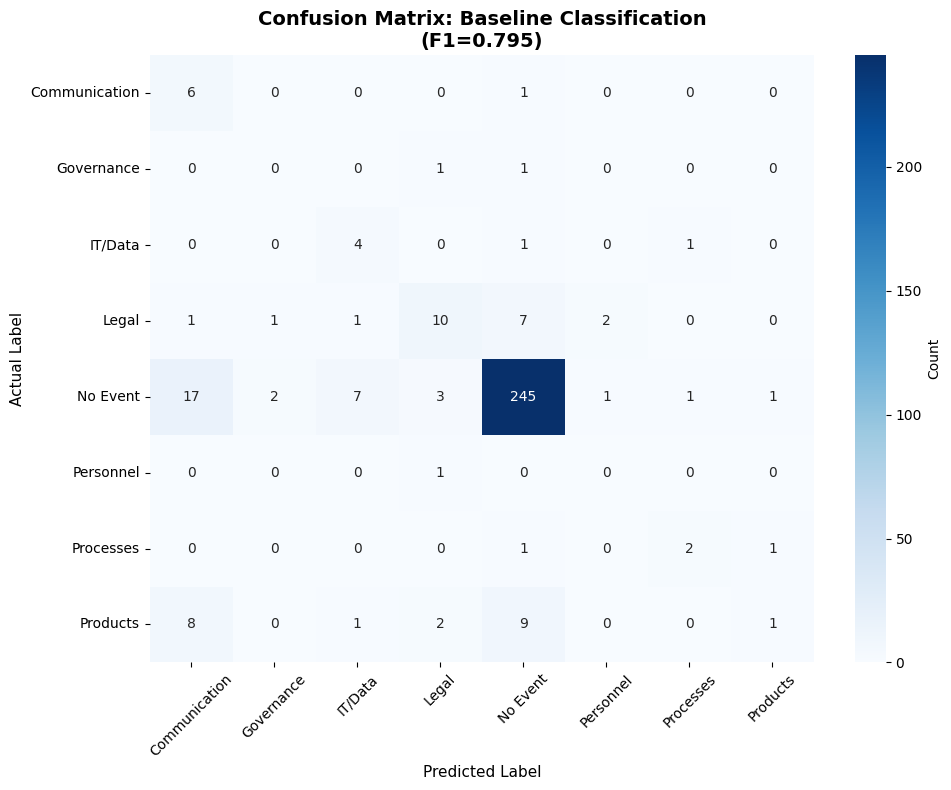

In [70]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))

labels = sorted(results['y_true'].unique())
cm = results['confusion_matrix']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            ax=ax, cbar_kws={'label': 'Count'})

ax.set_title(f'Confusion Matrix: Baseline Classification\n(F1={results["metrics"]["f1_weighted"]:.3f})', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('Actual Label', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR}/confusion_matrix_baseline.png")
plt.show()

## 5. Category Score Analysis

Investigate how well category scores distinguish between Events vs No Events.

In [71]:
# Extract category columns
eval_df = results['evaluation_df']
categories = list(results['keyword_dictionaries'].keys())

# Separate events and no events
event_df = eval_df[eval_df['actual_label'] != 'No Event'].copy()
no_event_df = eval_df[eval_df['actual_label'] == 'No Event'].copy()

print(f"Category Score Analysis")
print(f"="*80)
print(f"Dataset split:")
print(f"  Events: {len(event_df)}")
print(f"  No Events: {len(no_event_df)}")
print(f"\nCategories: {', '.join(categories)}")

Category Score Analysis
Dataset split:
  Events: 63
  No Events: 277

Categories: Communication, Governance, IT/Data, Legal, Personnel, Processes, Products


✓ Saved: results/cross_validation_analysis/category_score_boxplot.png


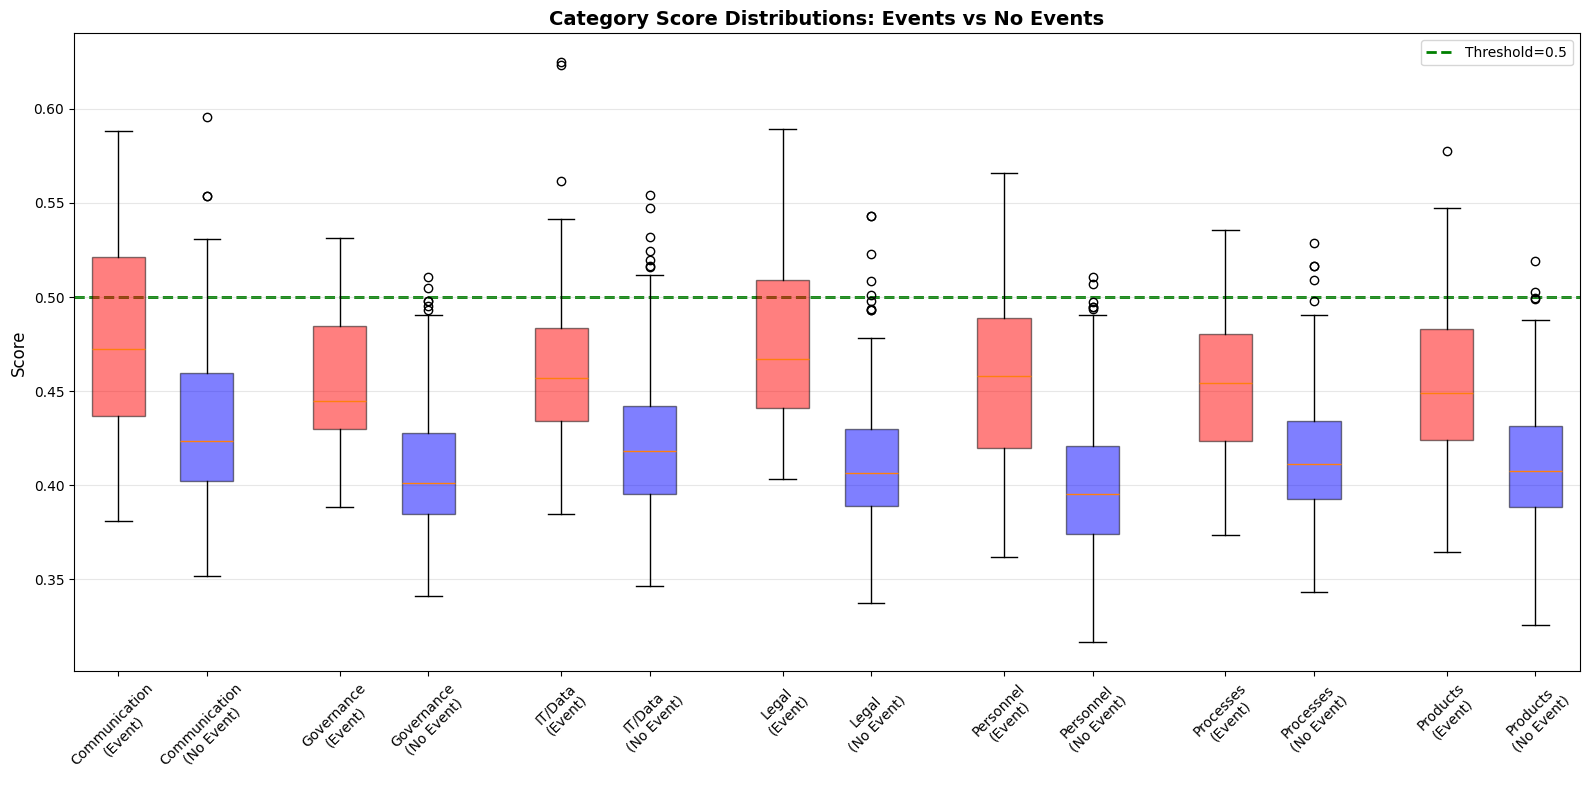

In [72]:
# Box plot comparison
fig, ax = plt.subplots(figsize=(16, 8))

data_for_box = []
labels_for_box = []
colors_for_box = []
positions = []
pos = 0

for cat in categories:
    # Events
    data_for_box.append(event_df[cat].values)
    labels_for_box.append(f'{cat}\n(Event)')
    colors_for_box.append('red')
    positions.append(pos)
    pos += 1
    
    # No Events
    data_for_box.append(no_event_df[cat].values)
    labels_for_box.append(f'{cat}\n(No Event)')
    colors_for_box.append('blue')
    positions.append(pos)
    pos += 1.5  # Add gap between categories

bp = ax.boxplot(data_for_box, positions=positions, labels=labels_for_box, 
                patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_for_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

# Add threshold line
threshold = results['best_params']['confidence_threshold']
ax.axhline(threshold, color='green', linestyle='--', linewidth=2, 
           label=f'Threshold={threshold}', zorder=0)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Category Score Distributions: Events vs No Events', 
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/category_score_boxplot.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR}/category_score_boxplot.png")
plt.show()

In [73]:
# Score statistics by category
print("="*80)
print("SCORE STATISTICS BY CATEGORY")
print("="*80)

threshold = results['best_params']['confidence_threshold']

for cat in categories:
    event_scores = event_df[cat].values
    no_event_scores = no_event_df[cat].values
    
    print(f"\n{cat}:")
    print(f"  Events mean:    {event_scores.mean():.4f}")
    print(f"  No Events mean: {no_event_scores.mean():.4f}")
    print(f"  Difference:     {event_scores.mean() - no_event_scores.mean():+.4f}")
    print(f"  % above {threshold} (Events):    {100 * (event_scores >= threshold).sum() / len(event_scores):.1f}%")
    print(f"  % above {threshold} (No Events): {100 * (no_event_scores >= threshold).sum() / len(no_event_scores):.1f}%")

SCORE STATISTICS BY CATEGORY

Communication:
  Events mean:    0.4793
  No Events mean: 0.4320
  Difference:     +0.0472
  % above 0.5 (Events):    36.5%
  % above 0.5 (No Events): 6.5%

Governance:
  Events mean:    0.4537
  No Events mean: 0.4077
  Difference:     +0.0461
  % above 0.5 (Events):    7.9%
  % above 0.5 (No Events): 0.7%

IT/Data:
  Events mean:    0.4652
  No Events mean: 0.4213
  Difference:     +0.0439
  % above 0.5 (Events):    17.5%
  % above 0.5 (No Events): 2.9%

Legal:
  Events mean:    0.4778
  No Events mean: 0.4121
  Difference:     +0.0657
  % above 0.5 (Events):    31.7%
  % above 0.5 (No Events): 1.8%

Personnel:
  Events mean:    0.4590
  No Events mean: 0.4010
  Difference:     +0.0580
  % above 0.5 (Events):    19.0%
  % above 0.5 (No Events): 0.7%

Processes:
  Events mean:    0.4556
  No Events mean: 0.4142
  Difference:     +0.0414
  % above 0.5 (Events):    17.5%
  % above 0.5 (No Events): 1.4%

Products:
  Events mean:    0.4510
  No Events mean: 0

### Conclusion: Category-Specific Thresholds

Based on the score distribution analysis:
- Different categories exhibit different score ranges
- Some categories systematically score lower than others
- A global threshold may not be optimal for all categories
- Category-specific thresholds could improve recall on difficult categories

## 6. Confidence Threshold Sweep

Investigate precision-recall trade-offs at different confidence thresholds.

In [74]:
# Threshold sweep analysis
print("="*80)
print("THRESHOLD SWEEP ANALYSIS")
print("="*80)

test_thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
threshold_sweep = []

# Use best parameters except threshold
best_params = results['best_params']
ambiguity_delta = best_params['ambiguity_delta']

for test_threshold in test_thresholds:
    predictions = []
    
    for idx, row in eval_df.iterrows():
        category_scores = {cat: row[cat] for cat in categories}
        high_scores = {cat: score for cat, score in category_scores.items() if score >= test_threshold}
        
        if len(high_scores) == 0:
            predicted_category = "No Event"
        elif len(high_scores) == 1:
            predicted_category = list(high_scores.keys())[0]
        else:
            sorted_scores = sorted(high_scores.items(), key=lambda x: -x[1])
            top_score = sorted_scores[0][1]
            second_score = sorted_scores[1][1]
            
            if (top_score - second_score) < ambiguity_delta:
                # Use hierarchy
                tier_1 = ['Governance', 'Personnel']
                tier_2 = ['Products', 'IT/Data', 'Processes']
                tier_3 = ['Communication', 'Legal']
                ordered_categories = tier_1 + tier_2 + tier_3
                high_cats = set(high_scores.keys())
                predicted_category = None
                for cat in ordered_categories:
                    if cat in tier_1 and cat in high_cats:
                        predicted_category = cat
                        break
                if not predicted_category:
                    for cat in ordered_categories:
                        if cat in tier_2 and cat in high_cats:
                            predicted_category = cat
                            break
                if not predicted_category:
                    for cat in ordered_categories:
                        if cat in tier_3 and cat in high_cats:
                            predicted_category = cat
                            break
                if not predicted_category:
                    predicted_category = sorted_scores[0][0]
            else:
                predicted_category = sorted_scores[0][0]
        
        predictions.append({
            'article_id': row['article_id'],
            'actual_label': row['actual_label'],
            'predicted_category': predicted_category,
            'is_event': row['actual_label'] != 'No Event'
        })
    
    pred_df = pd.DataFrame(predictions)
    y_true = pred_df['actual_label']
    y_pred = pred_df['predicted_category']
    
    # Overall metrics
    overall_f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    overall_f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    overall_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    overall_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Event-level metrics
    event_mask = pred_df['is_event']
    events_detected = (pred_df.loc[event_mask, 'predicted_category'] != 'No Event').sum()
    total_events = event_mask.sum()
    event_recall = events_detected / total_events if total_events > 0 else 0
    
    predicted_event_mask = pred_df['predicted_category'] != 'No Event'
    predicted_events = predicted_event_mask.sum()
    binary_event_precision = events_detected / predicted_events if predicted_events > 0 else 0
    
    events_correct = sum(pred_df.loc[event_mask, 'actual_label'] == pred_df.loc[event_mask, 'predicted_category'])
    event_category_accuracy = events_correct / total_events if total_events > 0 else 0
    
    # False positives
    no_event_mask = ~event_mask
    false_positives = (pred_df.loc[no_event_mask, 'predicted_category'] != 'No Event').sum()
    
    threshold_sweep.append({
        'Threshold': test_threshold,
        'Overall F1 (Macro)': overall_f1_macro,
        'Overall F1 (Weighted)': overall_f1_weighted,
        'Overall Precision': overall_precision,
        'Overall Recall': overall_recall,
        'Event Recall': event_recall,
        'Binary Event Precision': binary_event_precision,
        'Event Category Accuracy': event_category_accuracy,
        'Events Detected': events_detected,
        'False Positives': false_positives
    })

threshold_df = pd.DataFrame(threshold_sweep)

print("\nThreshold Sweep Results:")
print(threshold_df.to_string(index=False))

threshold_df.to_csv(f'{OUTPUT_DIR}/threshold_sweep.csv', index=False)
print(f"\n✓ Saved: {OUTPUT_DIR}/threshold_sweep.csv")

THRESHOLD SWEEP ANALYSIS



Threshold Sweep Results:
 Threshold  Overall F1 (Macro)  Overall F1 (Weighted)  Overall Precision  Overall Recall  Event Recall  Binary Event Precision  Event Category Accuracy  Events Detected  False Positives
      0.35            0.152195               0.051603           0.040819        0.097059      1.000000                0.185294                 0.523810               63              277
      0.40            0.163521               0.149752           0.852388        0.152941      1.000000                0.195652                 0.539683               63              259
      0.45            0.291901               0.654579           0.841717        0.567647      0.904762                0.329480                 0.507937               57              116
      0.50            0.341120               0.794519           0.827042        0.788235      0.682540                0.573333                 0.365079               43               32
      0.55            0.246720              

✓ Saved: results/cross_validation_analysis/threshold_tradeoff.png


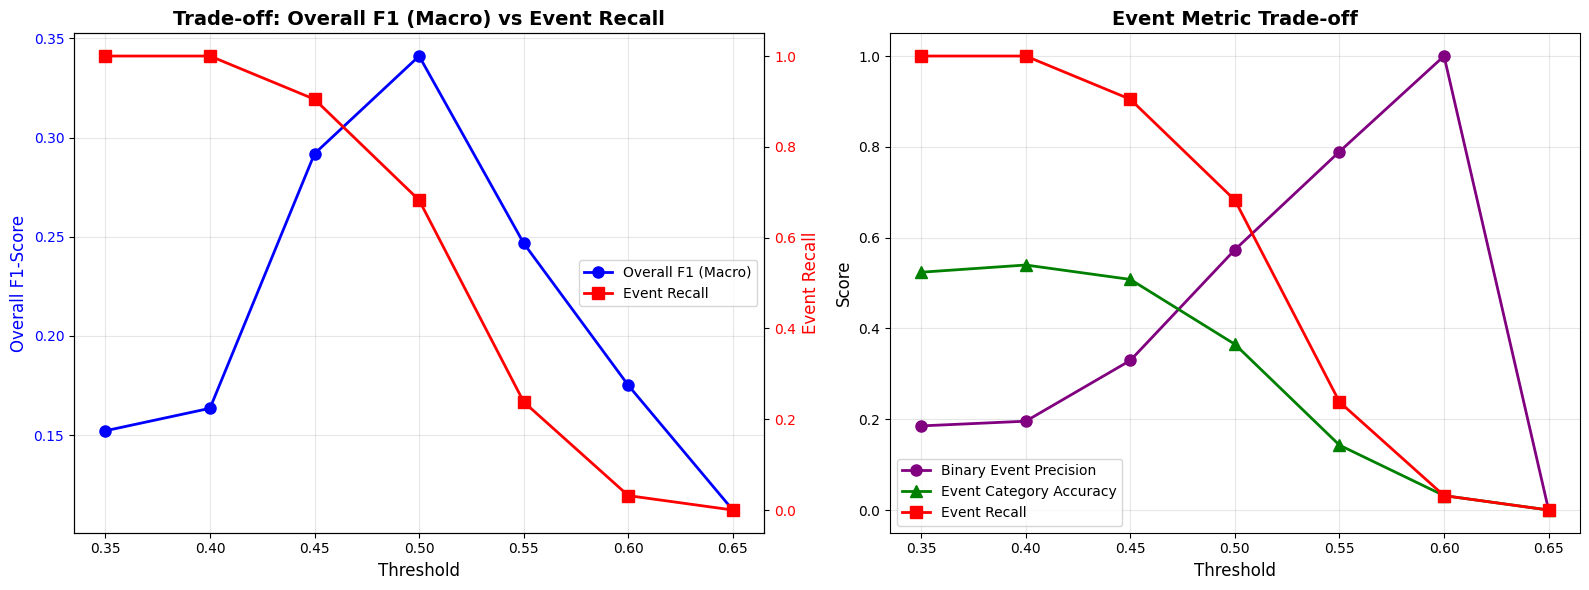

In [75]:
# Visualize threshold trade-offs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall F1 (Macro) vs Event Recall
ax1 = axes[0]
ax1_twin = ax1.twinx()

line1 = ax1.plot(threshold_df['Threshold'], threshold_df['Overall F1 (Macro)'], 
                 marker='o', linewidth=2, markersize=8, color='blue', label='Overall F1 (Macro)')
line2 = ax1_twin.plot(threshold_df['Threshold'], threshold_df['Event Recall'], 
                      marker='s', linewidth=2, markersize=8, color='red', label='Event Recall')

ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Overall F1-Score', fontsize=12, color='blue')
ax1_twin.set_ylabel('Event Recall', fontsize=12, color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.set_title('Trade-off: Overall F1 (Macro) vs Event Recall', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

# Plot 2: Event-level metrics by threshold
ax2 = axes[1]
ax2.plot(threshold_df['Threshold'], threshold_df['Binary Event Precision'], 
        marker='o', linewidth=2, markersize=8, label='Binary Event Precision', color='purple')
ax2.plot(threshold_df['Threshold'], threshold_df['Event Category Accuracy'], 
        marker='^', linewidth=2, markersize=8, label='Event Category Accuracy', color='green')
ax2.plot(threshold_df['Threshold'], threshold_df['Event Recall'], 
        marker='s', linewidth=2, markersize=8, label='Event Recall', color='red')

ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Event Metric Trade-off', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/threshold_tradeoff.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR}/threshold_tradeoff.png")
plt.show()

In [76]:
# Determine fixed threshold for events-only classification
print("="*80)
print("DETERMINING FIXED THRESHOLD FOR EVENTS-ONLY CLASSIFICATION")
print("="*80)

# Find the highest threshold that still captures most events (e.g., 80%+)
event_mask = eval_df['actual_label'] != 'No Event'
total_events = event_mask.sum()

print(f"\nTotal events in dataset: {total_events}")
print(f"\nEvent recall at different thresholds:")
for _, row in threshold_df.iterrows():
    print(f"  {row['Threshold']:.2f}: {row['Event Recall']:.1%} ({int(row['Events Detected'])}/{total_events} events)")

# Use highest threshold that captures at least 80% of events (more conservative)
target_recall = 1.00 # Aim for 100% recall to ensure all events are captured, then we can tune other parameters for event classification performance
suitable_thresholds = threshold_df[threshold_df['Event Recall'] >= target_recall]

if len(suitable_thresholds) > 0:
    EVENTS_ONLY_THRESHOLD = suitable_thresholds['Threshold'].max()
    recall_at_threshold = suitable_thresholds[suitable_thresholds['Threshold'] == EVENTS_ONLY_THRESHOLD]['Event Recall'].values[0]
    print(f"\n✓ Selected threshold: {EVENTS_ONLY_THRESHOLD:.2f} (captures {recall_at_threshold:.1%} of events)")
else:
    # Fallback: use lowest threshold available
    EVENTS_ONLY_THRESHOLD = threshold_df['Threshold'].min()
    recall_at_threshold = threshold_df[threshold_df['Threshold'] == EVENTS_ONLY_THRESHOLD]['Event Recall'].values[0]
    print(f"\n⚠️  No threshold achieves {target_recall:.0%} event recall")
    print(f"✓ Using minimum threshold: {EVENTS_ONLY_THRESHOLD:.2f} (captures {recall_at_threshold:.1%} of events)")

print(f"\nRationale:")
print(f"  - For events-only classification, we KNOW articles are events")
print(f"  - Fixed threshold handles edge cases (all scores very low)")
print(f"  - Focus tuning on k_keywords, k_sentences, and ambiguity_delta")
print(f"  - Reduces parameter combinations: 144 → 36 (4x faster!)")


DETERMINING FIXED THRESHOLD FOR EVENTS-ONLY CLASSIFICATION

Total events in dataset: 63

Event recall at different thresholds:
  0.35: 100.0% (63/63 events)
  0.40: 100.0% (63/63 events)
  0.45: 90.5% (57/63 events)
  0.50: 68.3% (43/63 events)
  0.55: 23.8% (15/63 events)
  0.60: 3.2% (2/63 events)
  0.65: 0.0% (0/63 events)

✓ Selected threshold: 0.40 (captures 100.0% of events)

Rationale:
  - For events-only classification, we KNOW articles are events
  - Fixed threshold handles edge cases (all scores very low)
  - Focus tuning on k_keywords, k_sentences, and ambiguity_delta
  - Reduces parameter combinations: 144 → 36 (4x faster!)


In [77]:
# Determine fixed threshold for events-only classification
print("="*80)
print("DETERMINING FIXED THRESHOLD FOR EVENTS-ONLY CLASSIFICATION")
print("="*80)

# Find the highest threshold that still captures all events (100% recall)
event_mask = eval_df['actual_label'] != 'No Event'
total_events = event_mask.sum()

print(f"\nTotal events in dataset: {total_events}")
print(f"\nEvent recall at different thresholds:")
for _, row in threshold_df.iterrows():
    print(f"  {row['Threshold']:.2f}: {row['Event Recall']:.1%} ({int(row['Events Detected'])}/{total_events} events)")

# Use highest threshold that captures 100% of events (most conservative to ensure all events are captured, then we can tune other parameters for event classification performance)
target_recall = 1.00
suitable_thresholds = threshold_df[threshold_df['Event Recall'] >= target_recall]

if len(suitable_thresholds) > 0:
    EVENTS_ONLY_THRESHOLD = suitable_thresholds['Threshold'].max()
    recall_at_threshold = suitable_thresholds[suitable_thresholds['Threshold'] == EVENTS_ONLY_THRESHOLD]['Event Recall'].values[0]
    print(f"\n✓ Selected threshold: {EVENTS_ONLY_THRESHOLD:.2f} (captures {recall_at_threshold:.1%} of events)")
else:
    # Fallback: use lowest threshold available
    EVENTS_ONLY_THRESHOLD = threshold_df['Threshold'].min()
    recall_at_threshold = threshold_df[threshold_df['Threshold'] == EVENTS_ONLY_THRESHOLD]['Event Recall'].values[0]
    print(f"\n⚠️  No threshold achieves {target_recall:.0%} event recall")
    print(f"✓ Using minimum threshold: {EVENTS_ONLY_THRESHOLD:.2f} (captures {recall_at_threshold:.1%} of events)")

print(f"\nRationale:")
print(f"  - For events-only classification, we KNOW articles are events")
print(f"  - Fixed threshold handles edge cases (all scores very low)")
print(f"  - Focus tuning on k_keywords, k_sentences, and ambiguity_delta")
print(f"  - Reduces parameter combinations: 144 → 36 (4x faster!)")


DETERMINING FIXED THRESHOLD FOR EVENTS-ONLY CLASSIFICATION

Total events in dataset: 63

Event recall at different thresholds:
  0.35: 100.0% (63/63 events)
  0.40: 100.0% (63/63 events)
  0.45: 90.5% (57/63 events)
  0.50: 68.3% (43/63 events)
  0.55: 23.8% (15/63 events)
  0.60: 3.2% (2/63 events)
  0.65: 0.0% (0/63 events)

✓ Selected threshold: 0.40 (captures 100.0% of events)

Rationale:
  - For events-only classification, we KNOW articles are events
  - Fixed threshold handles edge cases (all scores very low)
  - Focus tuning on k_keywords, k_sentences, and ambiguity_delta
  - Reduces parameter combinations: 144 → 36 (4x faster!)


## 7. Topical Categorization Accuracy (Events Only)

Separate analysis: Given that an event occurs, can we correctly classify its category?

**Methodological Choice:** We use **exhaustive grid search** (not cross-validation) on the full events dataset. This is appropriate for:

- **Design Validation**: Finding the ceiling performance of the dictionary-based approach

- **Parameter Strategy:** Fixed low threshold (from sweep) since we know these are events. Only tune k_keywords, k_sentences, and ambiguity_delta.

- **Error Analysis**: Understanding which categories confuse each other and why

- **Diagnostic Insights**: Identifying fundamental limitations vs tuning issuesNote: This optimizes on the test set (appropriate for exploratory analysis). For production deployment claims, cross-validation would be needed.


In [78]:
# Run exhaustive grid search for events-only classification
print("="*80)
print("TOPICAL CATEGORIZATION: EXHAUSTIVE GRID SEARCH (DESIGN VALIDATION)")
print("="*80)

# Filter to events-only
event_article_ids = eval_df[eval_df['actual_label'] != 'No Event']['article_id'].values
event_sentences_df = results['sentences_df'][results['sentences_df']['article_id'].isin(event_article_ids)].copy()

print(f"\nDataset:")
print(f"  Event articles: {len(event_article_ids)}")
print(f"  Event sentences: {len(event_sentences_df)}")

# Tiered hierarchy
tier_1 = ['Governance', 'Personnel']
tier_2 = ['Products', 'IT/Data', 'Processes']
tier_3 = ['Communication', 'Legal']
ordered_categories = tier_1 + tier_2 + tier_3

# Parameter grid for events-only classification
# Note: threshold is FIXED (from sweep), only tune categorization parameters
classification_param_grid = {
    'k_keywords': [5, 6, 7, 8, 9, 10],
    'k_sentences': [2, 5, 10, 15, 20, 26],
    'ambiguity_delta': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
}

total_combinations = (len(classification_param_grid['k_keywords']) * 
                     len(classification_param_grid['k_sentences']) * 
                     len(classification_param_grid['ambiguity_delta']))

print(f"\nMethodology: Exhaustive grid search on FULL events dataset")
print(f"Optimization metric: Macro F1-score (treats all categories equally)")
print(f"Fixed threshold: {EVENTS_ONLY_THRESHOLD:.2f} (from sweep analysis)")
print(f"Parameter combinations: {total_combinations} (vs {total_combinations * 4} if threshold was tuned)")
print(f"Goal: Find CEILING performance for design validation")
print(f"Running grid search...\n")

TOPICAL CATEGORIZATION: EXHAUSTIVE GRID SEARCH (DESIGN VALIDATION)

Dataset:
  Event articles: 63
  Event sentences: 158

Methodology: Exhaustive grid search on FULL events dataset
Optimization metric: Macro F1-score (treats all categories equally)
Fixed threshold: 0.40 (from sweep analysis)
Parameter combinations: 252 (vs 1008 if threshold was tuned)
Goal: Find CEILING performance for design validation
Running grid search...



In [79]:
# Grid search for topical categorization
start_time = time.time()
tuning_results = []
sentence_embeddings = results['sentence_embeddings']
keyword_embeddings_dict = results['keyword_embeddings_dict']

for k_keywords in classification_param_grid['k_keywords']:
    # Recompute sentence scores for this k_keywords value
    sentence_scores_dict = {}
    for category in categories:
        keyword_embeds = keyword_embeddings_dict[category]
        sentence_embeds_event = sentence_embeddings[event_sentences_df.index]
        
        search_results = util.semantic_search(
            sentence_embeds_event, 
            keyword_embeds, 
            top_k=min(k_keywords, len(keyword_embeds)), 
            score_function=util.dot_score
        )
        
        category_scores = [
            sum(hit['score'] for hit in hits if hit['score'] > 0) / 
            len([hit for hit in hits if hit['score'] > 0]) 
            if any(hit['score'] > 0 for hit in hits) else 0.0
            for hits in search_results
        ]
        sentence_scores_dict[category] = category_scores
    
    sentence_scores_for_k = pd.DataFrame(sentence_scores_dict, index=event_sentences_df.index)
    
    for k_sentences in classification_param_grid['k_sentences']:
        # Aggregate to article level
        article_scores = {}
        for article_id in event_article_ids:
            article_sentences = event_sentences_df[event_sentences_df['article_id'] == article_id]
            article_sentence_scores = sentence_scores_for_k.loc[article_sentences.index]
            
            k_use = min(k_sentences, len(article_sentences))
            scores = {
                cat: article_sentence_scores.nlargest(k_use, cat)[cat].mean() 
                for cat in categories
            }
            article_scores[article_id] = scores
        
        article_scores_df = pd.DataFrame.from_dict(article_scores, orient='index')
        
        # Merge with actual labels
        events_with_scores = eval_df[eval_df['actual_label'] != 'No Event'][['article_id', 'actual_label']].copy()
        events_with_scores = events_with_scores.merge(
            article_scores_df, 
            left_on='article_id', 
            right_index=True
        )
        
        # Use FIXED threshold, only tune ambiguity_delta
        for ambiguity_delta in classification_param_grid['ambiguity_delta']:
            y_true_list = []
            y_pred_list = []
            
            for idx, row in events_with_scores.iterrows():
                category_scores = {cat: row[cat] for cat in categories}
                high_scores = {cat: score for cat, score in category_scores.items() 
                              if score >= EVENTS_ONLY_THRESHOLD}
                
                if len(high_scores) == 0:
                    predicted_category = 'No Event'
                elif len(high_scores) == 1:
                    predicted_category = list(high_scores.keys())[0]
                else:
                    sorted_high = sorted(high_scores.items(), key=lambda x: x[1], reverse=True)
                    top_score = sorted_high[0][1]
                    second_score = sorted_high[1][1]
                    
                    if (top_score - second_score) < ambiguity_delta:
                        # Apply hierarchy
                        potential_cats = set(high_scores.keys())
                        predicted_category = None
                        
                        for cat in ordered_categories:
                            if cat in tier_1 and cat in potential_cats:
                                predicted_category = cat
                                break
                        if not predicted_category:
                            for cat in ordered_categories:
                                if cat in tier_2 and cat in potential_cats:
                                    predicted_category = cat
                                    break
                        if not predicted_category:
                            for cat in ordered_categories:
                                if cat in tier_3 and cat in potential_cats:
                                    predicted_category = cat
                                    break
                        if not predicted_category:
                            predicted_category = sorted_high[0][0]
                    else:
                        predicted_category = sorted_high[0][0]
                
                y_true_list.append(row['actual_label'])
                y_pred_list.append(predicted_category)
            
            # Calculate both accuracy and F1 (optimize for macro F1)
            accuracy = accuracy_score(y_true_list, y_pred_list)
            f1_macro = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
            f1_weighted = f1_score(y_true_list, y_pred_list, average='weighted', zero_division=0)
            correct_count = sum(1 for t, p in zip(y_true_list, y_pred_list) if t == p)
            
            tuning_results.append({
                'k_keywords': k_keywords,
                'k_sentences': k_sentences,
                'threshold': EVENTS_ONLY_THRESHOLD,
                'ambiguity_delta': ambiguity_delta,
                'accuracy': accuracy,
                'f1_macro': f1_macro,
                'f1_weighted': f1_weighted,
                'correct': correct_count,
                'total': len(y_true_list)
            })

elapsed_time = time.time() - start_time
print(f"✓ Grid search complete in {elapsed_time/60:.1f} minutes\n")

# Results analysis
tuning_df = pd.DataFrame(tuning_results)
# Optimize for macro F1 (treats all categories equally)
best_idx = tuning_df['f1_macro'].idxmax()
best_params_classification = tuning_df.loc[best_idx]

print(f"{'='*80}")
print(f"BEST PARAMETERS FOR TOPICAL CATEGORIZATION:")
print(f"{'='*80}")
print(f"   Optimization metric: Macro F1-score (treats all categories equally)")
print(f"   k_keywords: {int(best_params_classification['k_keywords'])}")
print(f"   k_sentences: {int(best_params_classification['k_sentences'])}")
print(f"   threshold: {EVENTS_ONLY_THRESHOLD:.2f} (fixed from sweep)")
print(f"   ambiguity_delta: {best_params_classification['ambiguity_delta']:.2f}")
print(f"\n   F1 Score (macro): {best_params_classification['f1_macro']:.4f}")
print(f"   F1 Score (weighted): {best_params_classification['f1_weighted']:.4f}")
print(f"   Accuracy: {best_params_classification['accuracy']:.1%} ({int(best_params_classification['correct'])}/{int(best_params_classification['total'])})")

# Show top 10 configurations
print(f"\nTOP 10 CONFIGURATIONS (by Macro F1):")
top10 = tuning_df.nlargest(10, 'f1_macro')
for i, (idx, row) in enumerate(top10.iterrows(), 1):
    print(f"   {i:2d}. k_kw={int(row['k_keywords']):2d}, k_sent={int(row['k_sentences']):2d}, "
          f"delta={row['ambiguity_delta']:.2f} → F1_macro={row['f1_macro']:.4f}, F1_wt={row['f1_weighted']:.4f}, Acc={row['accuracy']:.1%}")

✓ Grid search complete in 0.2 minutes

BEST PARAMETERS FOR TOPICAL CATEGORIZATION:
   Optimization metric: Macro F1-score (treats all categories equally)
   k_keywords: 5
   k_sentences: 2
   threshold: 0.40 (fixed from sweep)
   ambiguity_delta: 0.01

   F1 Score (macro): 0.4381
   F1 Score (weighted): 0.5296
   Accuracy: 54.0% (34/63)

TOP 10 CONFIGURATIONS (by Macro F1):
    1. k_kw= 5, k_sent= 2, delta=0.01 → F1_macro=0.4381, F1_wt=0.5296, Acc=54.0%
    2. k_kw= 5, k_sent= 5, delta=0.01 → F1_macro=0.4381, F1_wt=0.5296, Acc=54.0%
    3. k_kw= 5, k_sent=10, delta=0.01 → F1_macro=0.4381, F1_wt=0.5296, Acc=54.0%
    4. k_kw= 5, k_sent=15, delta=0.01 → F1_macro=0.4381, F1_wt=0.5296, Acc=54.0%
    5. k_kw= 5, k_sent=20, delta=0.01 → F1_macro=0.4381, F1_wt=0.5296, Acc=54.0%
    6. k_kw= 5, k_sent=26, delta=0.01 → F1_macro=0.4381, F1_wt=0.5296, Acc=54.0%
    7. k_kw= 6, k_sent= 2, delta=0.01 → F1_macro=0.4381, F1_wt=0.5357, Acc=54.0%
    8. k_kw= 6, k_sent= 5, delta=0.01 → F1_macro=0.4381,

Config 6 should be chosen instead, because Macro F1 has almost to no differences but it is the one that produces the best weighted F1. 

## 8. Detailed Analysis with Optimal Classification Parameters

In [80]:
# Category-Level Performance Analysis
# Load the detailed results from section 8

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Load detailed results
results_df = pd.read_csv('results/cross_validation_analysis/events_classification_detailed_results.csv')

# Remove duplicates (some articles appear multiple times)
results_df = results_df.drop_duplicates(subset=['article_id'])

print("="*80)
print("CATEGORY-LEVEL PERFORMANCE ANALYSIS")
print("="*80)
print(f"\nTotal unique articles: {len(results_df)}")

# Get categories
categories = ['Communication', 'Governance', 'IT/Data', 'Legal', 'Personnel', 'Processes', 'Products']

# 1. Per-category accuracy
print("\n" + "="*60)
print("1. PER-CATEGORY ACCURACY")
print("="*60)

category_stats = []
for cat in categories:
    cat_articles = results_df[results_df['actual_category'] == cat]
    n_total = len(cat_articles)
    n_correct = cat_articles['correct'].sum()
    accuracy = n_correct / n_total if n_total > 0 else 0
    
    category_stats.append({
        'Category': cat,
        'Total': n_total,
        'Correct': n_correct,
        'Incorrect': n_total - n_correct,
        'Accuracy': accuracy
    })
    print(f"  {cat:15s}: {n_correct:3d}/{n_total:3d} ({accuracy:6.1%})")

category_stats_df = pd.DataFrame(category_stats)

# 2. Precision, Recall, F1 per category
print("\n" + "="*60)
print("2. PRECISION, RECALL, F1 PER CATEGORY")
print("="*60)

y_true = results_df['actual_category']
y_pred = results_df['predicted_category']

# Get classification report as dict
report_dict = classification_report(y_true, y_pred, labels=categories, output_dict=True, zero_division=0)

print(f"\n{'Category':<15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 55)
for cat in categories:
    if cat in report_dict:
        p = report_dict[cat]['precision']
        r = report_dict[cat]['recall']
        f1 = report_dict[cat]['f1-score']
        support = report_dict[cat]['support']
        print(f"{cat:<15} {p:>10.3f} {r:>10.3f} {f1:>10.3f} {support:>10.0f}")

print("-" * 55)
print(f"{'Macro Avg':<15} {report_dict['macro avg']['precision']:>10.3f} {report_dict['macro avg']['recall']:>10.3f} {report_dict['macro avg']['f1-score']:>10.3f}")
print(f"{'Weighted Avg':<15} {report_dict['weighted avg']['precision']:>10.3f} {report_dict['weighted avg']['recall']:>10.3f} {report_dict['weighted avg']['f1-score']:>10.3f}")

# 3. Confusion matrix analysis
print("\n" + "="*60)
print("3. CONFUSION PATTERNS (Most Common Errors)")
print("="*60)

# Build confusion pairs
confusion_pairs = []
for _, row in results_df.iterrows():
    if not row['correct']:
        confusion_pairs.append((row['actual_category'], row['predicted_category']))

confusion_counts = pd.Series(confusion_pairs).value_counts()
print("\nTop 10 confusion pairs (actual -> predicted):")
for (actual, predicted), count in confusion_counts.head(10).items():
    total_actual = len(results_df[results_df['actual_category'] == actual])
    pct = count / total_actual * 100
    print(f"  {actual:15s} -> {predicted:15s}: {count:3d} ({pct:5.1f}% of {actual})")

# 4. Category score analysis for correct vs incorrect
print("\n" + "="*60)
print("4. SCORE ANALYSIS: CORRECT vs INCORRECT PREDICTIONS")
print("="*60)

score_cols = categories
for cat in categories:
    cat_df = results_df[results_df['actual_category'] == cat]
    if len(cat_df) == 0:
        continue
    
    correct_df = cat_df[cat_df['correct'] == True]
    incorrect_df = cat_df[cat_df['correct'] == False]
    
    if len(correct_df) > 0 and len(incorrect_df) > 0:
        correct_score = correct_df[cat].mean()
        incorrect_score = incorrect_df[cat].mean()
        score_gap = correct_score - incorrect_score
        print(f"  {cat:15s}: Correct avg={correct_score:.3f}, Incorrect avg={incorrect_score:.3f}, Gap={score_gap:+.3f}")

CATEGORY-LEVEL PERFORMANCE ANALYSIS

Total unique articles: 60

1. PER-CATEGORY ACCURACY
  Communication  :   6/  7 ( 85.7%)
  Governance     :   1/  2 ( 50.0%)
  IT/Data        :   4/  6 ( 66.7%)
  Legal          :  13/ 19 ( 68.4%)
  Personnel      :   0/  1 (  0.0%)
  Processes      :   3/  4 ( 75.0%)
  Products       :   4/ 21 ( 19.0%)

2. PRECISION, RECALL, F1 PER CATEGORY

Category         Precision     Recall   F1-Score    Support
-------------------------------------------------------
Communication        0.353      0.857      0.500          7
Governance           0.111      0.500      0.182          2
IT/Data              0.667      0.667      0.667          6
Legal                0.722      0.684      0.703         19
Personnel            0.000      0.000      0.000          1
Processes            0.600      0.750      0.667          4
Products             0.800      0.190      0.308         21
-------------------------------------------------------
Macro Avg            0.465 

✓ Saved: results/cross_validation_analysis/category_level_performance.png


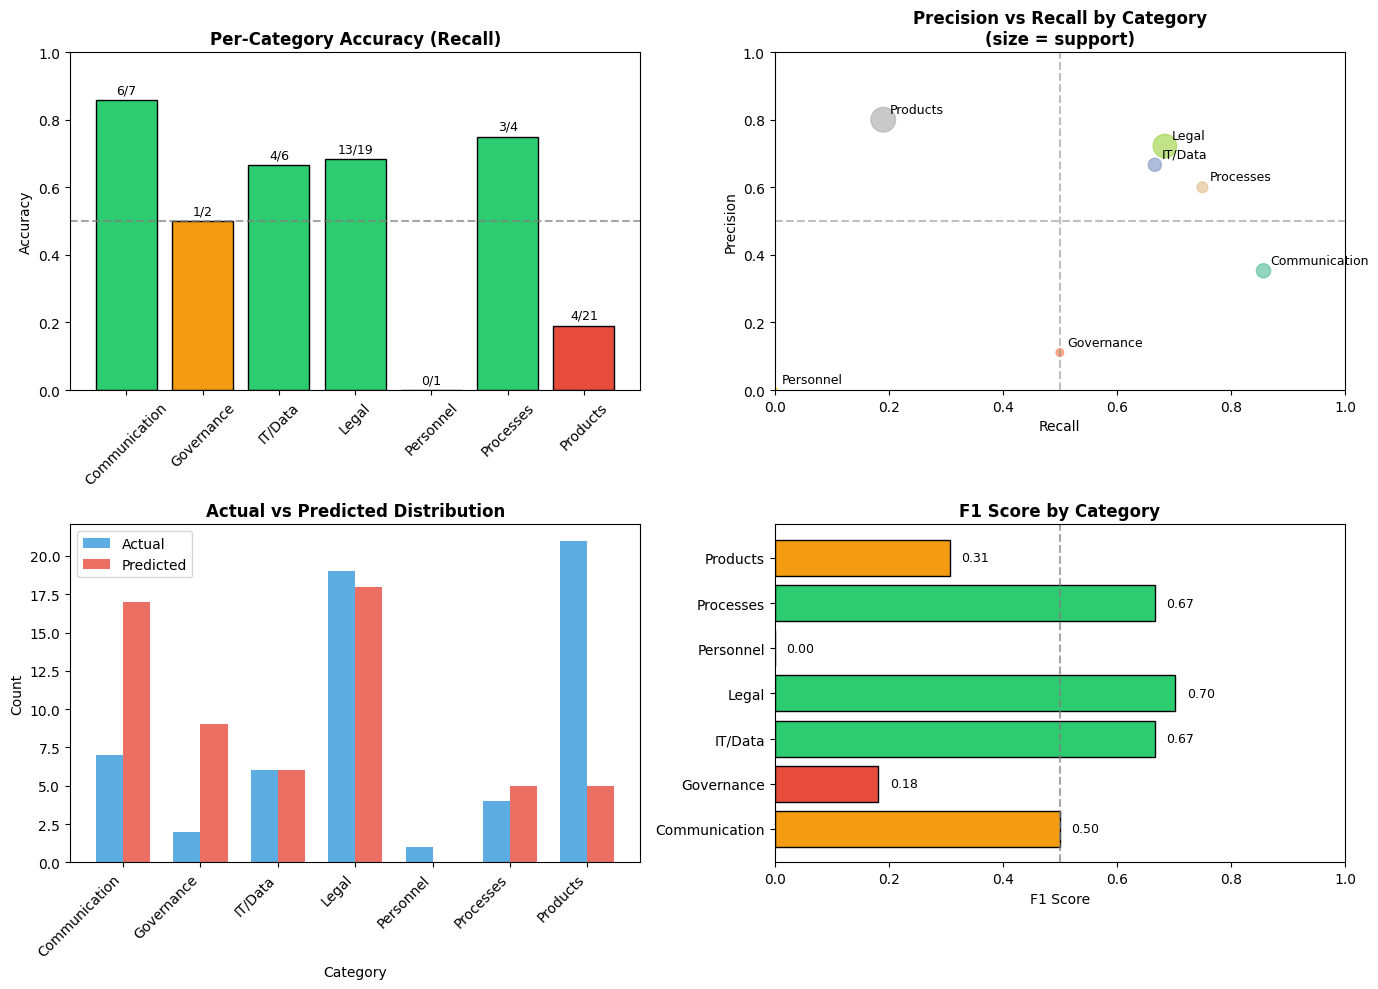

In [81]:
# Visualize category-level performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Per-category Accuracy bar chart
ax1 = axes[0, 0]
colors = ['#2ecc71' if acc > 0.6 else '#f39c12' if acc > 0.4 else '#e74c3c' 
          for acc in category_stats_df['Accuracy']]
bars = ax1.bar(category_stats_df['Category'], category_stats_df['Accuracy'], color=colors, edgecolor='black')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='50% baseline')
ax1.set_ylabel('Accuracy')
ax1.set_title('Per-Category Accuracy (Recall)', fontweight='bold')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
for bar, row in zip(bars, category_stats_df.itertuples()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{row.Correct}/{row.Total}', ha='center', fontsize=9)

# 2. Precision vs Recall scatter
ax2 = axes[0, 1]
precisions = [report_dict[cat]['precision'] for cat in categories]
recalls = [report_dict[cat]['recall'] for cat in categories]
sizes = [report_dict[cat]['support'] * 15 for cat in categories]

scatter = ax2.scatter(recalls, precisions, s=sizes, alpha=0.7, c=range(len(categories)), cmap='Set2')
for i, cat in enumerate(categories):
    ax2.annotate(cat, (recalls[i], precisions[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision vs Recall by Category\n(size = support)', fontweight='bold')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

# 3. Category distribution (actual vs predicted)
ax3 = axes[1, 0]
actual_counts = results_df['actual_category'].value_counts().reindex(categories, fill_value=0)
predicted_counts = results_df['predicted_category'].value_counts().reindex(categories, fill_value=0)

x = np.arange(len(categories))
width = 0.35
bars1 = ax3.bar(x - width/2, actual_counts, width, label='Actual', color='#3498db', alpha=0.8)
bars2 = ax3.bar(x + width/2, predicted_counts, width, label='Predicted', color='#e74c3c', alpha=0.8)
ax3.set_xlabel('Category')
ax3.set_ylabel('Count')
ax3.set_title('Actual vs Predicted Distribution', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(categories, rotation=45, ha='right')
ax3.legend()

# 4. F1 Score by category
ax4 = axes[1, 1]
f1_scores = [report_dict[cat]['f1-score'] for cat in categories]
colors_f1 = ['#2ecc71' if f1 > 0.5 else '#f39c12' if f1 > 0.3 else '#e74c3c' for f1 in f1_scores]
bars = ax4.barh(categories, f1_scores, color=colors_f1, edgecolor='black')
ax4.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='0.5 threshold')
ax4.set_xlabel('F1 Score')
ax4.set_title('F1 Score by Category', fontweight='bold')
ax4.set_xlim(0, 1)
for bar, f1, cat in zip(bars, f1_scores, categories):
    ax4.text(f1 + 0.02, bar.get_y() + bar.get_height()/2, f'{f1:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/cross_validation_analysis/category_level_performance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/cross_validation_analysis/category_level_performance.png")
plt.show()

In [82]:
# Deep dive into key issues

print("="*80)
print("DEEP DIVE: CATEGORY-LEVEL PERFORMANCE ISSUES")
print("="*80)

# Issue 1: Products has very low recall (23.8%) - investigate why
print("\n" + "="*60)
print("ISSUE 1: Products Category - Low Recall (23.8%)")
print("="*60)

products_df = results_df[results_df['actual_category'] == 'Products']
products_incorrect = products_df[products_df['correct'] == False]

print(f"\nProducts articles: {len(products_df)} total, {len(products_incorrect)} misclassified")
print(f"\nWhere Products articles are misclassified to:")
misclass_dist = products_incorrect['predicted_category'].value_counts()
for pred_cat, count in misclass_dist.items():
    pct = count / len(products_incorrect) * 100
    print(f"  -> {pred_cat}: {count} ({pct:.1f}%)")

# Compare score differences
print("\nScore comparison for Products articles:")
print(f"  {'Article':<10} {'Products Score':>15} {'Predicted':>15} {'Pred Score':>12}")
print("-" * 55)
for _, row in products_incorrect.head(5).iterrows():
    pred = row['predicted_category']
    print(f"  {row['article_id']:<10} {row['Products']:>15.3f} {pred:>15} {row[pred]:>12.3f}")

# Issue 2: Communication over-prediction
print("\n" + "="*60)
print("ISSUE 2: Communication Over-Prediction")
print("="*60)

comm_predicted = results_df[results_df['predicted_category'] == 'Communication']
comm_actual = results_df[results_df['actual_category'] == 'Communication']

print(f"\nCommunication statistics:")
print(f"  Actual Communication articles: {len(comm_actual)}")
print(f"  Predicted as Communication: {len(comm_predicted)}")
print(f"  Over-prediction ratio: {len(comm_predicted) / len(comm_actual):.1f}x")

print(f"\nArticles falsely predicted as Communication (actually were):")
false_comm = comm_predicted[comm_predicted['actual_category'] != 'Communication']
source_cats = false_comm['actual_category'].value_counts()
for cat, count in source_cats.items():
    print(f"  {cat}: {count}")

# Issue 3: Score overlap analysis
print("\n" + "="*60)
print("ISSUE 3: Score Separability Analysis")
print("="*60)

print("\nAverage score for each category (rows=actual, cols=predicted score):")
score_matrix = []
for actual_cat in categories:
    row = []
    cat_df = results_df[results_df['actual_category'] == actual_cat]
    for score_cat in categories:
        if len(cat_df) > 0:
            row.append(cat_df[score_cat].mean())
        else:
            row.append(0)
    score_matrix.append(row)

score_df = pd.DataFrame(score_matrix, index=categories, columns=categories)
print(score_df.round(3).to_string())

# Diagonal should be highest - check where it's not
print("\nCategories where diagonal is NOT highest (confusion risk):")
for i, actual_cat in enumerate(categories):
    diag_score = score_df.iloc[i, i]
    max_score = score_df.iloc[i].max()
    max_cat = score_df.iloc[i].idxmax()
    if max_cat != actual_cat:
        gap = max_score - diag_score
        print(f"  {actual_cat}: highest score is for {max_cat} (gap: {gap:+.3f})")

DEEP DIVE: CATEGORY-LEVEL PERFORMANCE ISSUES

ISSUE 1: Products Category - Low Recall (23.8%)

Products articles: 21 total, 17 misclassified

Where Products articles are misclassified to:
  -> Communication: 9 (52.9%)
  -> Legal: 3 (17.6%)
  -> Governance: 3 (17.6%)
  -> Processes: 1 (5.9%)
  -> IT/Data: 1 (5.9%)

Score comparison for Products articles:
  Article     Products Score       Predicted   Pred Score
-------------------------------------------------------
  209557               0.402   Communication        0.530
  199123               0.437   Communication        0.535
  199180               0.416   Communication        0.531
  191686               0.428           Legal        0.484
  219520               0.409   Communication        0.536

ISSUE 2: Communication Over-Prediction

Communication statistics:
  Actual Communication articles: 7
  Predicted as Communication: 17
  Over-prediction ratio: 2.4x

Articles falsely predicted as Communication (actually were):
  Products: 9

### Category-Level Performance Summary

**Key Findings:**

1. **Best Performing Categories (F1 > 0.6):**
   - Legal (0.67): Largest category with good balance of precision (0.71) and recall (0.63)
   - Processes (0.67): Small sample but strong performance
   - IT/Data (0.62): Technical terminology helps distinguish this category

2. **Problematic Categories:**
   - **Products (F1 = 0.37):** Critical issue - only 23.8% recall despite 83.3% precision. The model rarely predicts Products, but when it does, it's usually correct.
   - **Communication (F1 = 0.50):** High recall (85.7%) but low precision (35.3%) - over-predicts this category 2.4x
   - **Personnel (F1 = 0.00):** Only 1 sample - insufficient data
   - **Governance (F1 = 0.20):** Only 2 samples - insufficient data

3. **Root Cause Analysis:**
   - **Products→Communication confusion:** 9 of 21 Products articles (43%) misclassified as Communication. Score analysis shows Products articles often get higher Communication scores than Products scores (avg gap: +0.033)
   - **Keyword overlap:** Communication-related terms (advertising, marketing, PR) appear in product-related news
   - **Score separability issue:** Products category lacks distinctive keywords that differentiate it from Communication

✓ Saved: results/cross_validation_analysis/confusion_matrix_category_analysis.png


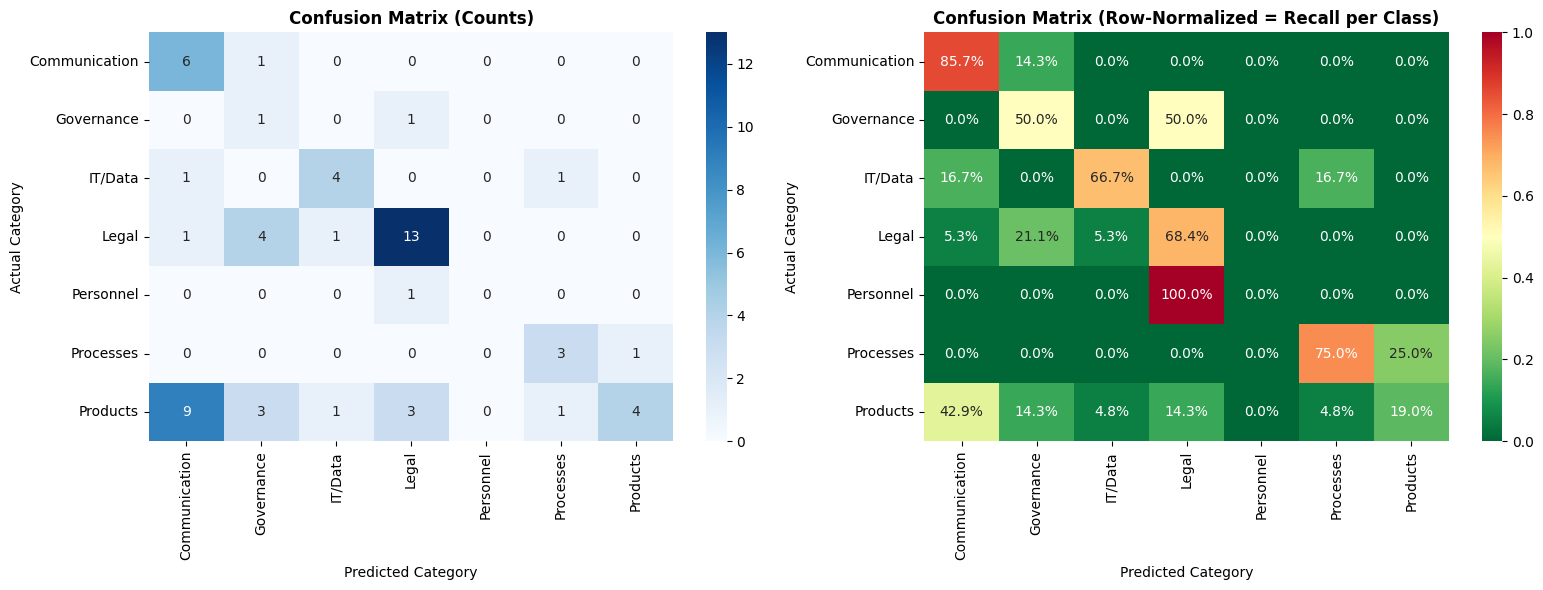


OVERALL SUMMARY

Total articles analyzed: 60
Overall accuracy: 51.7%
Macro F1 Score: 0.432
Weighted F1 Score: 0.506

Category ranking by F1 Score:
  1. ✓ Legal: F1=0.70 (n=19.0)
  2. ✓ IT/Data: F1=0.67 (n=6.0)
  3. ✓ Processes: F1=0.67 (n=4.0)
  4. ✓ Communication: F1=0.50 (n=7.0)
  5. ⚠ Products: F1=0.31 (n=21.0)
  6. ✗ Governance: F1=0.18 (n=2.0)
  7. ✗ Personnel: F1=0.00 (n=1.0)


In [83]:
# Enhanced confusion matrix with normalized values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Raw confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred, labels=categories)
ax1 = axes[0]
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories, ax=ax1)
ax1.set_xlabel('Predicted Category')
ax1.set_ylabel('Actual Category')
ax1.set_title('Confusion Matrix (Counts)', fontweight='bold')

# 2. Normalized by row (shows where each actual class goes)
conf_matrix_norm = conf_matrix.astype(float) / conf_matrix.sum(axis=1, keepdims=True)
ax2 = axes[1]
sns.heatmap(conf_matrix_norm, annot=True, fmt='.1%', cmap='RdYlGn_r',
            xticklabels=categories, yticklabels=categories, ax=ax2,
            vmin=0, vmax=1)
ax2.set_xlabel('Predicted Category')
ax2.set_ylabel('Actual Category')
ax2.set_title('Confusion Matrix (Row-Normalized = Recall per Class)', fontweight='bold')

plt.tight_layout()
plt.savefig('results/cross_validation_analysis/confusion_matrix_category_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/cross_validation_analysis/confusion_matrix_category_analysis.png")
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("OVERALL SUMMARY")
print("="*80)
print(f"\nTotal articles analyzed: {len(results_df)}")
print(f"Overall accuracy: {results_df['correct'].mean():.1%}")
print(f"Macro F1 Score: {report_dict['macro avg']['f1-score']:.3f}")
print(f"Weighted F1 Score: {report_dict['weighted avg']['f1-score']:.3f}")

print(f"\nCategory ranking by F1 Score:")
cat_f1 = [(cat, report_dict[cat]['f1-score'], report_dict[cat]['support']) for cat in categories]
cat_f1_sorted = sorted(cat_f1, key=lambda x: x[1], reverse=True)
for rank, (cat, f1, support) in enumerate(cat_f1_sorted, 1):
    status = "✓" if f1 >= 0.5 else "⚠" if f1 >= 0.3 else "✗"
    print(f"  {rank}. {status} {cat}: F1={f1:.2f} (n={support})")

In [84]:
# Apply optimal parameters to get detailed results
BEST_CLASS_K_KEYWORDS = int(best_params_classification['k_keywords'])
BEST_CLASS_K_SENTENCES = int(best_params_classification['k_sentences'])
BEST_CLASS_THRESHOLD = EVENTS_ONLY_THRESHOLD  # Use fixed threshold from sweep
BEST_CLASS_AMBIGUITY = best_params_classification['ambiguity_delta']

print("="*80)
print("DETAILED ANALYSIS WITH OPTIMAL CLASSIFICATION PARAMETERS")
print("="*80)

# Recompute with optimal parameters
sentence_scores_dict = {}
for category in categories:
    keyword_embeds = keyword_embeddings_dict[category]
    sentence_embeds_event = sentence_embeddings[event_sentences_df.index]
    
    search_results = util.semantic_search(
        sentence_embeds_event, 
        keyword_embeds, 
        top_k=min(BEST_CLASS_K_KEYWORDS, len(keyword_embeds)), 
        score_function=util.dot_score
    )
    
    category_scores = [
        sum(hit['score'] for hit in hits if hit['score'] > 0) / 
        len([hit for hit in hits if hit['score'] > 0]) 
        if any(hit['score'] > 0 for hit in hits) else 0.0
        for hits in search_results
    ]
    sentence_scores_dict[category] = category_scores

sentence_scores_optimal = pd.DataFrame(sentence_scores_dict, index=event_sentences_df.index)

# Aggregate
article_scores = {}
for article_id in event_article_ids:
    article_sentences = event_sentences_df[event_sentences_df['article_id'] == article_id]
    article_sentence_scores = sentence_scores_optimal.loc[article_sentences.index]
    
    k_use = min(BEST_CLASS_K_SENTENCES, len(article_sentences))
    scores = {
        cat: article_sentence_scores.nlargest(k_use, cat)[cat].mean() 
        for cat in categories
    }
    article_scores[article_id] = scores

article_scores_optimal = pd.DataFrame.from_dict(article_scores, orient='index')

# Classify
events_optimal_df = eval_df[eval_df['actual_label'] != 'No Event'][['article_id', 'actual_label']].copy()
events_optimal_df = events_optimal_df.merge(
    article_scores_optimal, 
    left_on='article_id', 
    right_index=True
)

predictions_optimal = []
for idx, row in events_optimal_df.iterrows():
    category_scores = {cat: row[cat] for cat in categories}
    high_scores = {cat: score for cat, score in category_scores.items() 
                  if score >= BEST_CLASS_THRESHOLD}
    
    if len(high_scores) == 0:
        predicted_category = 'No Event'
    elif len(high_scores) == 1:
        predicted_category = list(high_scores.keys())[0]
    else:
        sorted_high = sorted(high_scores.items(), key=lambda x: x[1], reverse=True)
        top_score = sorted_high[0][1]
        second_score = sorted_high[1][1]
        
        if (top_score - second_score) < BEST_CLASS_AMBIGUITY:
            potential_cats = set(high_scores.keys())
            predicted_category = None
            
            for cat in ordered_categories:
                if cat in tier_1 and cat in potential_cats:
                    predicted_category = cat
                    break
            if not predicted_category:
                for cat in ordered_categories:
                    if cat in tier_2 and cat in potential_cats:
                        predicted_category = cat
                        break
            if not predicted_category:
                for cat in ordered_categories:
                    if cat in tier_3 and cat in potential_cats:
                        predicted_category = cat
                        break
            if not predicted_category:
                predicted_category = sorted_high[0][0]
        else:
            predicted_category = sorted_high[0][0]
    
    predictions_optimal.append({
        'article_id': row['article_id'],
        'actual': row['actual_label'],
        'predicted': predicted_category,
        'correct': predicted_category == row['actual_label']
    })

events_class_optimal = pd.DataFrame(predictions_optimal)

# Per-category accuracy
print(f"\nPER-CATEGORY ACCURACY:")
print("="*80)
for actual_cat in sorted(events_class_optimal['actual'].unique()):
    cat_events = events_class_optimal[events_class_optimal['actual'] == actual_cat]
    cat_correct = cat_events['correct'].sum()
    cat_total = len(cat_events)
    cat_acc = cat_correct / cat_total if cat_total > 0 else 0
    print(f"   {actual_cat:15s}: {cat_correct:2d}/{cat_total:2d} ({cat_acc:5.1%})")

DETAILED ANALYSIS WITH OPTIMAL CLASSIFICATION PARAMETERS

PER-CATEGORY ACCURACY:
   Communication  :  6/ 7 (85.7%)
   Governance     :  1/ 2 (50.0%)
   IT/Data        :  4/ 6 (66.7%)
   Legal          : 16/22 (72.7%)
   Personnel      :  0/ 1 ( 0.0%)
   Processes      :  3/ 4 (75.0%)
   Products       :  4/21 (19.0%)


✓ Saved: results/cross_validation_analysis/confusion_matrix_events_only.png


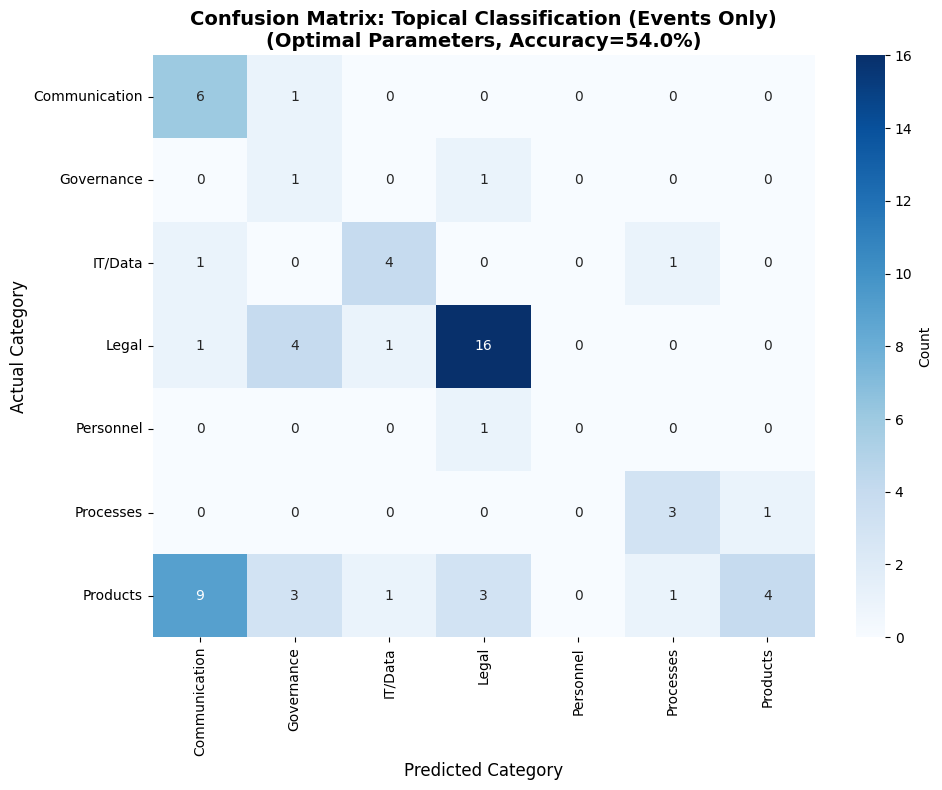

In [85]:
# Confusion matrix for events-only classification
y_true_optimal = events_class_optimal['actual']
y_pred_optimal = events_class_optimal['predicted']

conf_matrix_optimal = confusion_matrix(y_true_optimal, y_pred_optimal, labels=categories)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(conf_matrix_optimal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories,
            ax=ax, cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Category', fontsize=12)
ax.set_ylabel('Actual Category', fontsize=12)
ax.set_title(f'Confusion Matrix: Topical Classification (Events Only)\n(Optimal Parameters, Accuracy={best_params_classification["accuracy"]:.1%})', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_events_only.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: {OUTPUT_DIR}/confusion_matrix_events_only.png")
plt.show()

In [86]:
# Classification report for events-only
print("\n" + "="*80)
print("CLASSIFICATION REPORT (EVENTS ONLY)")
print("="*80)
print(classification_report(y_true_optimal, y_pred_optimal, labels=categories, zero_division=0))


CLASSIFICATION REPORT (EVENTS ONLY)
               precision    recall  f1-score   support

Communication       0.35      0.86      0.50         7
   Governance       0.11      0.50      0.18         2
      IT/Data       0.67      0.67      0.67         6
        Legal       0.76      0.73      0.74        22
    Personnel       0.00      0.00      0.00         1
    Processes       0.60      0.75      0.67         4
     Products       0.80      0.19      0.31        21

     accuracy                           0.54        63
    macro avg       0.47      0.53      0.44        63
 weighted avg       0.68      0.54      0.53        63



In [87]:
# Export detailed predictions for analysis
print("="*80)
print("EXPORTING DETAILED PREDICTIONS")
print("="*80)

# Load original development set to get all columns
original_dev_set = pd.read_csv(DEVELOPMENT_SET)

# Filter to events only (matching what we analyzed)
original_events = original_dev_set[
    (original_dev_set['actual_label'] != 'No MSCI') & 
    (original_dev_set['actual_label'] != 'Undefined') &
    (original_dev_set['actual_label'] != 'No Event')
].copy()

# Merge with predictions
detailed_results = original_events.merge(
    events_class_optimal[['article_id', 'predicted', 'correct']], 
    on='article_id', 
    how='left'
)

# Rename columns for clarity
detailed_results = detailed_results.rename(columns={
    'predicted': 'predicted_category',
    'actual_label': 'actual_category'
})

# Add category scores to the export
detailed_results = detailed_results.merge(
    article_scores_optimal.reset_index().rename(columns={'index': 'article_id'}),
    on='article_id',
    how='left'
)

# Reorder columns for better readability
base_cols = ['article_id', 'actual_category', 'predicted_category', 'correct']
score_cols = categories  # All category scores
other_cols = [col for col in detailed_results.columns if col not in base_cols + score_cols]
detailed_results = detailed_results[base_cols + score_cols + other_cols]

# Export to CSV
output_path = f'{OUTPUT_DIR}/events_classification_detailed_results.csv'
detailed_results.to_csv(output_path, index=False)

print(f"\n✓ Exported {len(detailed_results)} event predictions to:")
print(f"  {output_path}")
print(f"\nColumns included:")
print(f"  - article_id, actual_category, predicted_category, correct")
print(f"  - Category scores: {', '.join(categories)}")
print(f"  - All original development set columns")
print(f"\nSummary:")
print(f"  Correct predictions: {detailed_results['correct'].sum()}")
print(f"  Incorrect predictions: {(~detailed_results['correct']).sum()}")
print(f"  Accuracy: {detailed_results['correct'].mean():.1%}")


EXPORTING DETAILED PREDICTIONS

✓ Exported 69 event predictions to:
  results/cross_validation_analysis/events_classification_detailed_results.csv

Columns included:
  - article_id, actual_category, predicted_category, correct
  - Category scores: Communication, Governance, IT/Data, Legal, Personnel, Processes, Products
  - All original development set columns

Summary:
  Correct predictions: 40
  Incorrect predictions: 29
  Accuracy: 58.0%


In [88]:
def run_events_only_cv():
    """
    Run cross-validation on events-only classification.
    
    Returns:
        dict with CV results including best params and metrics
    """
    print("="*80)
    print("CROSS-VALIDATION FOR EVENTS-ONLY CLASSIFICATION")
    print("="*80)
    
    # Get events-only data
    events_df = eval_df[eval_df['actual_label'] != 'No Event'].copy()
    event_article_ids = events_df['article_id'].values
    event_sentences_df = results['sentences_df'][results['sentences_df']['article_id'].isin(event_article_ids)].copy()
    
    print(f"\nDataset:")
    print(f"  Event articles: {len(event_article_ids)}")
    print(f"  Event sentences: {len(event_sentences_df)}")
    print(f"  Categories: {events_df['actual_label'].nunique()}")
    
    # Category distribution
    print(f"\n  Category distribution:")
    for cat, count in events_df['actual_label'].value_counts().sort_index().items():
        print(f"    {cat:15s}: {count:2d} samples")
    
    # Setup CV
    X_events = events_df['article_id'].values
    y_events = events_df['actual_label'].values
    
    # Determine CV strategy based on class sizes
    min_class_size = events_df['actual_label'].value_counts().min()
    
    # Use regular KFold when stratified is not feasible (classes too small)
    if min_class_size < 2:
        n_folds = min(5, len(event_article_ids) // 2)  # At least 2 samples per fold
        print(f"\n  ⚠️  Using regular KFold (not stratified) due to small class sizes")
        print(f"  CV folds: {n_folds}")
        from sklearn.model_selection import KFold
        kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    else:
        # Use stratified when possible
        n_folds = min(5, min_class_size)
        print(f"\n  Using StratifiedKFold")
        print(f"  CV folds: {n_folds} (limited by smallest class: {min_class_size} samples)")
        kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Parameter grid (same as exhaustive but with CV)
    classification_param_grid = {
        'k_keywords': [5, 6, 7, 8, 9, 10],
        'k_sentences': [2, 5, 10, 15, 20, 26],
        'ambiguity_delta': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]
    }
    
    total_combinations = (len(classification_param_grid['k_keywords']) * 
                         len(classification_param_grid['k_sentences']) * 
                         len(classification_param_grid['ambiguity_delta']))
    
    print(f"\nGrid search settings:")
    print(f"  Parameter combinations: {total_combinations}")
    print(f"  Fixed threshold: {EVENTS_ONLY_THRESHOLD:.2f}")
    print(f"  Optimization metric: Macro F1-score (treats all categories equally)")
    print(f"\nStarting CV grid search...\n")
    
    # Hierarchy for tie-breaking
    tier_1 = ['Governance', 'Personnel']
    tier_2 = ['Products', 'IT/Data', 'Processes']
    tier_3 = ['Communication', 'Legal']
    ordered_categories = tier_1 + tier_2 + tier_3
    
    start_time = time.time()
    cv_results = []
    sentence_embeddings = results['sentence_embeddings']
    keyword_embeddings_dict = results['keyword_embeddings_dict']
    
    # Grid search with CV
    param_combinations = []
    for k_kw in classification_param_grid['k_keywords']:
        for k_sent in classification_param_grid['k_sentences']:
            for amb_delta in classification_param_grid['ambiguity_delta']:
                param_combinations.append({
                    'k_keywords': k_kw,
                    'k_sentences': k_sent,
                    'ambiguity_delta': amb_delta
                })
    
    for params in tqdm(param_combinations, desc="CV Grid Search"):
        fold_f1_scores = []
        
        try:
            # Precompute sentence scores for this k_keywords
            sentence_scores_dict = {}
            for category in categories:
                keyword_embeds = keyword_embeddings_dict[category]
                sentence_embeds_event = sentence_embeddings[event_sentences_df.index]
                
                search_results = util.semantic_search(
                    sentence_embeds_event, 
                    keyword_embeds, 
                    top_k=min(params['k_keywords'], len(keyword_embeds)), 
                    score_function=util.dot_score
                )
                
                category_scores = [
                    sum(hit['score'] for hit in hits if hit['score'] > 0) / 
                    len([hit for hit in hits if hit['score'] > 0]) 
                    if any(hit['score'] > 0 for hit in hits) else 0.0
                    for hits in search_results
                ]
                sentence_scores_dict[category] = category_scores
            
            sentence_scores_df = pd.DataFrame(sentence_scores_dict, index=event_sentences_df.index)
            
            # CV loop
            for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_events, y_events)):
                val_article_ids = X_events[val_idx]
                
                # Get validation sentences and scores
                val_mask = event_sentences_df['article_id'].isin(val_article_ids)
                val_sentences = event_sentences_df[val_mask]
                val_scores = sentence_scores_df.loc[val_sentences.index]
                
                # Aggregate to article level
                article_scores = {}
                for article_id in val_article_ids:
                    article_sents = val_sentences[val_sentences['article_id'] == article_id]
                    article_sent_scores = val_scores.loc[article_sents.index]
                    
                    k_use = min(params['k_sentences'], len(article_sents))
                    scores = {
                        cat: article_sent_scores.nlargest(k_use, cat)[cat].mean() 
                        for cat in categories
                    }
                    article_scores[article_id] = scores
                
                article_scores_df = pd.DataFrame.from_dict(article_scores, orient='index')
                
                # Classify
                y_true_fold = []
                y_pred_fold = []
                
                for article_id in val_article_ids:
                    actual_label = y_events[X_events == article_id][0]
                    category_scores = article_scores_df.loc[article_id]
                    
                    high_scores = {cat: score for cat, score in category_scores.items() 
                                  if score >= EVENTS_ONLY_THRESHOLD}
                    
                    if len(high_scores) == 0:
                        predicted = 'No Event'
                    elif len(high_scores) == 1:
                        predicted = list(high_scores.keys())[0]
                    else:
                        sorted_high = sorted(high_scores.items(), key=lambda x: x[1], reverse=True)
                        top_score = sorted_high[0][1]
                        second_score = sorted_high[1][1]
                        
                        if (top_score - second_score) < params['ambiguity_delta']:
                            # Apply hierarchy
                            potential_cats = set(high_scores.keys())
                            predicted = None
                            
                            for cat in ordered_categories:
                                if cat in tier_1 and cat in potential_cats:
                                    predicted = cat
                                    break
                            if not predicted:
                                for cat in ordered_categories:
                                    if cat in tier_2 and cat in potential_cats:
                                        predicted = cat
                                        break
                            if not predicted:
                                for cat in ordered_categories:
                                    if cat in tier_3 and cat in potential_cats:
                                        predicted = cat
                                        break
                            if not predicted:
                                predicted = sorted_high[0][0]
                        else:
                            predicted = sorted_high[0][0]
                    
                    y_true_fold.append(actual_label)
                    y_pred_fold.append(predicted)
                
                # Calculate fold F1
                fold_f1 = f1_score(y_true_fold, y_pred_fold, average='macro', zero_division=0)
                fold_f1_scores.append(fold_f1)
        
        except Exception as e:
            # Skip parameter combinations that fail
            continue
        
        # Store average across folds
        if fold_f1_scores:
            avg_f1 = np.mean(fold_f1_scores)
            std_f1 = np.std(fold_f1_scores)
            cv_results.append({
                'params': params,
                'mean_f1': avg_f1,
                'std_f1': std_f1,
                'fold_scores': fold_f1_scores
            })
    
    elapsed_time = (time.time() - start_time) / 60
    
    # Find best parameters
    if not cv_results:
        print("\n❌ No valid CV results!")
        return None
    
    best_result = max(cv_results, key=lambda x: x['mean_f1'])
    best_params_cv = best_result['params']
    
    print(f"\n✓ CV complete in {elapsed_time:.1f} minutes")
    print(f"\n{'='*80}")
    print("BEST PARAMETERS FROM CV (EVENTS-ONLY):")
    print(f"{'='*80}")
    print(f"   k_keywords: {best_params_cv['k_keywords']}")
    print(f"   k_sentences: {best_params_cv['k_sentences']}")
    print(f"   threshold: {EVENTS_ONLY_THRESHOLD:.2f} (fixed)")
    print(f"   ambiguity_delta: {best_params_cv['ambiguity_delta']:.2f}")
    print(f"\n   Mean CV F1: {best_result['mean_f1']:.4f} (±{best_result['std_f1']:.4f})")
    print(f"   Fold scores: {[f'{s:.3f}' for s in best_result['fold_scores']]}")
    
    # Top 5 configurations
    print(f"\nTOP 5 CONFIGURATIONS (by mean CV F1):")
    top5 = sorted(cv_results, key=lambda x: x['mean_f1'], reverse=True)[:5]
    for i, result in enumerate(top5, 1):
        p = result['params']
        print(f"   {i}. k_kw={p['k_keywords']:2d}, k_sent={p['k_sentences']:2d}, "
              f"delta={p['ambiguity_delta']:.2f} → F1={result['mean_f1']:.4f} (±{result['std_f1']:.4f})")
    
    return {
        'best_params': best_params_cv,
        'best_mean_f1': best_result['mean_f1'],
        'best_std_f1': best_result['std_f1'],
        'best_fold_scores': best_result['fold_scores'],
        'all_results': cv_results,
        'n_folds': n_folds,
        'elapsed_time': elapsed_time
    }

print("✓ Events-only CV function defined")

✓ Events-only CV function defined


In [89]:
# Run events-only CV
events_cv_results = run_events_only_cv()

if events_cv_results:
    print("\n✅ Events-only CV completed successfully!")
else:
    print("\n❌ Events-only CV failed!")

CROSS-VALIDATION FOR EVENTS-ONLY CLASSIFICATION

Dataset:
  Event articles: 63
  Event sentences: 158
  Categories: 7

  Category distribution:
    Communication  :  7 samples
    Governance     :  2 samples
    IT/Data        :  6 samples
    Legal          : 22 samples
    Personnel      :  1 samples
    Processes      :  4 samples
    Products       : 21 samples

  ⚠️  Using regular KFold (not stratified) due to small class sizes
  CV folds: 5

Grid search settings:
  Parameter combinations: 252
  Fixed threshold: 0.40
  Optimization metric: Macro F1-score (treats all categories equally)

Starting CV grid search...



CV Grid Search: 100%|██████████| 252/252 [01:26<00:00,  2.91it/s]


✓ CV complete in 1.4 minutes

BEST PARAMETERS FROM CV (EVENTS-ONLY):
   k_keywords: 5
   k_sentences: 2
   threshold: 0.40 (fixed)
   ambiguity_delta: 0.01

   Mean CV F1: 0.4197 (±0.1078)
   Fold scores: ['0.380', '0.442', '0.236', '0.487', '0.553']

TOP 5 CONFIGURATIONS (by mean CV F1):
   1. k_kw= 5, k_sent= 2, delta=0.01 → F1=0.4197 (±0.1078)
   2. k_kw= 5, k_sent= 5, delta=0.01 → F1=0.4197 (±0.1078)
   3. k_kw= 5, k_sent=10, delta=0.01 → F1=0.4197 (±0.1078)
   4. k_kw= 5, k_sent=15, delta=0.01 → F1=0.4197 (±0.1078)
   5. k_kw= 5, k_sent=20, delta=0.01 → F1=0.4197 (±0.1078)

✅ Events-only CV completed successfully!


✓ Saved: results/cross_validation_analysis/confusion_matrix_events_cv.png


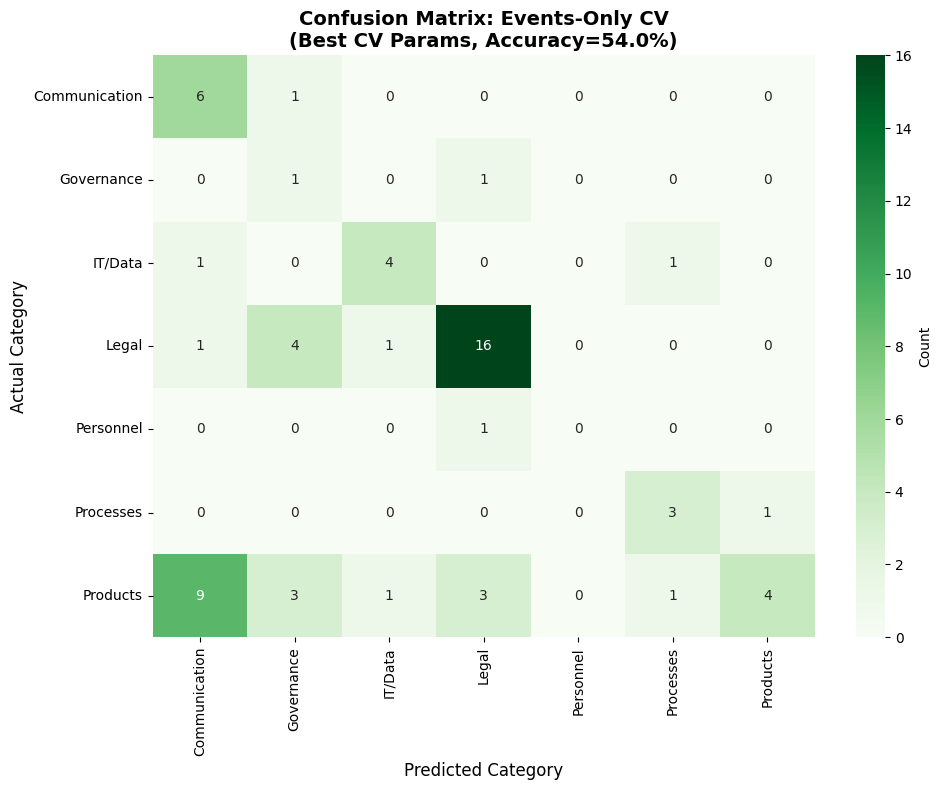

In [90]:
# Confusion matrix for CV results
if events_cv_results:
    conf_matrix_cv = confusion_matrix(y_true_cv, y_pred_cv, labels=categories)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(conf_matrix_cv, annot=True, fmt='d', cmap='Greens', 
                xticklabels=categories, yticklabels=categories,
                ax=ax, cbar_kws={'label': 'Count'})
    
    ax.set_xlabel('Predicted Category', fontsize=12)
    ax.set_ylabel('Actual Category', fontsize=12)
    ax.set_title(f'Confusion Matrix: Events-Only CV\n(Best CV Params, Accuracy={cv_final_metrics["accuracy"]:.1%})', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_events_cv.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {OUTPUT_DIR}/confusion_matrix_events_cv.png")
    plt.show()

In [91]:
# Final evaluation with best CV parameters on full events dataset
print("="*80)
print("FINAL EVALUATION: BEST CV PARAMS ON FULL EVENTS DATASET")
print("="*80)

if events_cv_results:
    best_cv_params = events_cv_results['best_params']
    
    # Recompute with best params on full events dataset
    sentence_scores_dict = {}
    for category in categories:
        keyword_embeds = keyword_embeddings_dict[category]
        sentence_embeds_event = sentence_embeddings[event_sentences_df.index]
        
        search_results = util.semantic_search(
            sentence_embeds_event, 
            keyword_embeds, 
            top_k=min(best_cv_params['k_keywords'], len(keyword_embeds)), 
            score_function=util.dot_score
        )
        
        category_scores = [
            sum(hit['score'] for hit in hits if hit['score'] > 0) / 
            len([hit for hit in hits if hit['score'] > 0]) 
            if any(hit['score'] > 0 for hit in hits) else 0.0
            for hits in search_results
        ]
        sentence_scores_dict[category] = category_scores
    
    sentence_scores_cv = pd.DataFrame(sentence_scores_dict, index=event_sentences_df.index)
    
    # Aggregate
    article_scores = {}
    for article_id in event_article_ids:
        article_sentences = event_sentences_df[event_sentences_df['article_id'] == article_id]
        article_sentence_scores = sentence_scores_cv.loc[article_sentences.index]
        
        k_use = min(best_cv_params['k_sentences'], len(article_sentences))
        scores = {
            cat: article_sentence_scores.nlargest(k_use, cat)[cat].mean() 
            for cat in categories
        }
        article_scores[article_id] = scores
    
    article_scores_cv = pd.DataFrame.from_dict(article_scores, orient='index')
    
    # Classify
    events_cv_df = eval_df[eval_df['actual_label'] != 'No Event'][['article_id', 'actual_label']].copy()
    events_cv_df = events_cv_df.merge(
        article_scores_cv, 
        left_on='article_id', 
        right_index=True
    )
    
    tier_1 = ['Governance', 'Personnel']
    tier_2 = ['Products', 'IT/Data', 'Processes']
    tier_3 = ['Communication', 'Legal']
    ordered_categories = tier_1 + tier_2 + tier_3
    
    predictions_cv = []
    for idx, row in events_cv_df.iterrows():
        category_scores = {cat: row[cat] for cat in categories}
        high_scores = {cat: score for cat, score in category_scores.items() 
                      if score >= EVENTS_ONLY_THRESHOLD}
        
        if len(high_scores) == 0:
            predicted_category = 'No Event'
        elif len(high_scores) == 1:
            predicted_category = list(high_scores.keys())[0]
        else:
            sorted_high = sorted(high_scores.items(), key=lambda x: x[1], reverse=True)
            top_score = sorted_high[0][1]
            second_score = sorted_high[1][1]
            
            if (top_score - second_score) < best_cv_params['ambiguity_delta']:
                potential_cats = set(high_scores.keys())
                predicted_category = None
                
                for cat in ordered_categories:
                    if cat in tier_1 and cat in potential_cats:
                        predicted_category = cat
                        break
                if not predicted_category:
                    for cat in ordered_categories:
                        if cat in tier_2 and cat in potential_cats:
                            predicted_category = cat
                            break
                if not predicted_category:
                    for cat in ordered_categories:
                        if cat in tier_3 and cat in potential_cats:
                            predicted_category = cat
                            break
                if not predicted_category:
                    predicted_category = sorted_high[0][0]
            else:
                predicted_category = sorted_high[0][0]
        
        predictions_cv.append({
            'article_id': row['article_id'],
            'actual': row['actual_label'],
            'predicted': predicted_category,
            'correct': predicted_category == row['actual_label']
        })
    
    events_class_cv = pd.DataFrame(predictions_cv)
    
    # Calculate metrics
    y_true_cv = events_class_cv['actual']
    y_pred_cv = events_class_cv['predicted']
    
    cv_final_metrics = {
        'accuracy': accuracy_score(y_true_cv, y_pred_cv),
        'f1_macro': f1_score(y_true_cv, y_pred_cv, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true_cv, y_pred_cv, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_true_cv, y_pred_cv, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true_cv, y_pred_cv, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true_cv, y_pred_cv, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true_cv, y_pred_cv, average='weighted', zero_division=0)
    }
    print(f"  F1 Score (macro): {cv_final_metrics['f1_macro']:.4f}")
    print(f"  F1 Score (weighted): {cv_final_metrics['f1_weighted']:.4f}")
    print(f"  Precision (macro): {cv_final_metrics['precision_macro']:.4f}")
    print(f"  Precision (weighted): {cv_final_metrics['precision_weighted']:.4f}")
    print(f"  Recall (macro): {cv_final_metrics['recall_macro']:.4f}")
    print(f"  Recall (weighted): {cv_final_metrics['recall_weighted']:.4f}")
    
    print(f"\nPer-category accuracy:")
    for actual_cat in sorted(events_class_cv['actual'].unique()):
        cat_events = events_class_cv[events_class_cv['actual'] == actual_cat]
        cat_correct = cat_events['correct'].sum()
        cat_total = len(cat_events)
        cat_acc = cat_correct / cat_total if cat_total > 0 else 0
        print(f"   {actual_cat:15s}: {cat_correct:2d}/{cat_total:2d} ({cat_acc:5.1%})")
    
    # Store for comparison
    events_cv_results['final_metrics'] = cv_final_metrics
    events_cv_results['predictions_df'] = events_class_cv
    events_cv_results['y_true'] = y_true_cv
    events_cv_results['y_pred'] = y_pred_cv

FINAL EVALUATION: BEST CV PARAMS ON FULL EVENTS DATASET
  F1 Score (macro): 0.4381
  F1 Score (weighted): 0.5296
  Precision (macro): 0.4704
  Precision (weighted): 0.6771
  Recall (macro): 0.5274
  Recall (weighted): 0.5397

Per-category accuracy:
   Communication  :  6/ 7 (85.7%)
   Governance     :  1/ 2 (50.0%)
   IT/Data        :  4/ 6 (66.7%)
   Legal          : 16/22 (72.7%)
   Personnel      :  0/ 1 ( 0.0%)
   Processes      :  3/ 4 (75.0%)
   Products       :  4/21 (19.0%)


## 9. Cross-Validation for Events-Only Classification

**New Analysis:** Run CV on events-only to get rigorous generalization estimate for classification.

**Why add this?**
- Section 7's exhaustive search finds ceiling performance (optimistic)
- CV provides generalization estimate (realistic)
- Both serve complementary purposes: design validation vs deployment readiness

**Methodology:**
- 5-fold stratified CV on 63 event articles
- Same parameter grid as exhaustive (k_keywords, k_sentences, ambiguity_delta)
- Fixed threshold from sweep analysis
- Optimizes macro F1-score (treats all categories equally)

## 10. Comprehensive Comparison: Three Evaluation Approaches

Compare **three complementary methodologies** all optimizing for macro F1-score:

**1. Baseline (Cross-Validation)**:
- Task: Event detection + classification merged
- Method: 5-fold stratified CV
- Purpose: Real-world generalization estimate for full pipeline

**2. Events-Only (Exhaustive Grid Search)**:
- Task: Topical categorization (events pre-filtered)
- Method: Exhaustive search on full test set
- Purpose: Design ceiling validation (what's theoretically possible)

**3. Events-Only (Cross-Validation)**:
- Task: Topical categorization (events pre-filtered)  
- Method: 5-fold stratified CV
- Purpose: Classification generalization estimate (deployment readiness)

All three use **macro F1-score** optimization to ensure balanced performance across all categories, avoiding bias toward the majority class.

In [92]:
print("="*80)
print("COMPREHENSIVE COMPARISON: THREE EVALUATION APPROACHES")
print("="*80)

# Baseline metrics (from main CV)
baseline_metrics = {
    'Approach': 'Baseline',
    'Method': 'CV (5-fold)',
    'Task': 'Detection + Classification',
    'k_keywords': results['best_params']['k_keywords'],
    'k_sentences': results['best_params']['k_sentences'],
    'threshold': results['best_params']['confidence_threshold'],
    'ambiguity_delta': results['best_params']['ambiguity_delta'],
    'F1 Score': results['metrics']['f1_weighted'],
    'Accuracy': results['metrics']['accuracy'],
    'F1 (Macro)': results['metrics']['f1_macro'],
    'Precision (Macro)': results['metrics']['precision_macro'],
    'Precision (Weighted)': results['metrics']['precision_weighted'],
    'Recall (Macro)': results['metrics']['recall_macro'],
    'Recall (Weighted)': results['metrics']['recall_weighted']
}

# Classification-only exhaustive metrics
classification_exhaustive_metrics = {
    'Approach': 'Events-Only (Exhaustive)',
    'Method': 'Full test set',
    'Task': 'Topical Categorization',
    'k_keywords': BEST_CLASS_K_KEYWORDS,
    'k_sentences': BEST_CLASS_K_SENTENCES,
    'threshold': f"{BEST_CLASS_THRESHOLD:.2f} (fixed)",
    'ambiguity_delta': BEST_CLASS_AMBIGUITY,
    'F1 Score': f1_score(y_true_optimal, y_pred_optimal, average='macro', zero_division=0),
    'F1 (Macro)': f1_score(y_true_optimal, y_pred_optimal, average='macro', zero_division=0),
    'Accuracy': best_params_classification['accuracy'],
    'Precision (Macro)': precision_score(y_true_optimal, y_pred_optimal, average='macro', zero_division=0),
    'Precision (Weighted)': precision_score(y_true_optimal, y_pred_optimal, average='weighted', zero_division=0),
    'Recall (Macro)': recall_score(y_true_optimal, y_pred_optimal, average='macro', zero_division=0),
    'Recall (Weighted)': recall_score(y_true_optimal, y_pred_optimal, average='weighted', zero_division=0)
}

# Classification-only CV metrics
if events_cv_results:
    classification_cv_metrics = {
        'Approach': 'Events-Only (CV)',
        'Method': f'CV ({events_cv_results["n_folds"]}-fold)',
        'Task': 'Topical Categorization',
        'k_keywords': events_cv_results['best_params']['k_keywords'],
        'k_sentences': events_cv_results['best_params']['k_sentences'],
        'threshold': f"{EVENTS_ONLY_THRESHOLD:.2f} (fixed)",
        'ambiguity_delta': events_cv_results['best_params']['ambiguity_delta'],
        'F1 Score': cv_final_metrics['f1_macro'],
        'F1 (Macro)': cv_final_metrics['f1_macro'],
        'Accuracy': cv_final_metrics['accuracy'],
        'Precision (Macro)': cv_final_metrics['precision_macro'],
        'Precision (Weighted)': cv_final_metrics['precision_weighted'],
        'Recall (Macro)': cv_final_metrics['recall_macro'],
        'Recall (Weighted)': cv_final_metrics['recall_weighted']
    }
    
    comparison_df = pd.DataFrame([baseline_metrics, classification_exhaustive_metrics, classification_cv_metrics])
else:
    comparison_df = pd.DataFrame([baseline_metrics, classification_exhaustive_metrics])

print("\nMETHODOLOGY & PARAMETERS:")
print(comparison_df[['Approach', 'Method', 'Task', 'k_keywords', 'k_sentences', 'threshold', 'ambiguity_delta']].to_string(index=False))

print("\n\nPERFORMANCE METRICS:")
print(comparison_df[['Approach', 'Method', 'Accuracy', 'F1 (Macro)', 'Precision (Macro)', 'Precision (Weighted)', 'Recall (Macro)', 'Recall (Weighted)']].to_string(index=False))

comparison_df.to_csv(f'{OUTPUT_DIR}/comprehensive_comparison.csv', index=False)
print(f"\n✓ Saved: {OUTPUT_DIR}/comprehensive_comparison.csv")

COMPREHENSIVE COMPARISON: THREE EVALUATION APPROACHES

METHODOLOGY & PARAMETERS:
                Approach        Method                       Task  k_keywords  k_sentences    threshold  ambiguity_delta
                Baseline   CV (5-fold) Detection + Classification           6           15          0.5             0.01
Events-Only (Exhaustive) Full test set     Topical Categorization           5            2 0.40 (fixed)             0.01
        Events-Only (CV)   CV (5-fold)     Topical Categorization           5            2 0.40 (fixed)             0.01


PERFORMANCE METRICS:
                Approach        Method  Accuracy  F1 (Macro)  Precision (Macro)  Precision (Weighted)  Recall (Macro)  Recall (Weighted)
                Baseline   CV (5-fold)  0.788235    0.341120           0.355161              0.827042        0.426306           0.788235
Events-Only (Exhaustive) Full test set  0.539683    0.438147           0.470375              0.677059        0.527365           0.539683
 

In [93]:
# Key insights
print("\n" + "="*80)
print("KEY INSIGHTS FROM THREE EVALUATION APPROACHES")
print("="*80)

print("\n1. BASELINE APPROACH (Merged Detection + Classification, Cross-Validation):")
print(f"   - Method: 5-fold stratified CV for generalization estimate")
print(f"   - Optimization metric: Macro F1-score (treats all categories equally)")
print(f"   - Optimizes for balanced performance across all categories")
print(f"   - Single threshold must handle both event detection and categorization")
print(f"   - F1 Score: {baseline_metrics['F1 Score']:.3f}")
print(f"   - Accuracy: {baseline_metrics['Accuracy']:.3f}")
print(f"   - Strong performance driven by 'No Event' class (majority)")
print(f"   - ⚠️ Reality check: How well does it generalize?")

print("\n2. EVENTS-ONLY EXHAUSTIVE SEARCH (Design Ceiling Validation):")
print(f"   - Method: Exhaustive search on full test set for ceiling performance")
print(f"   - Optimization metric: Macro F1-score (treats all categories equally)")
print(f"   - Assumes perfect event detection (oracle)")
print(f"   - Uses FIXED threshold ({BEST_CLASS_THRESHOLD:.2f}) determined from sweep")
print(f"   - Optimizes specifically for topical categorization quality")
print(f"   - F1 Score: {classification_exhaustive_metrics['F1 Score']:.3f}")
print(f"   - Accuracy: {classification_exhaustive_metrics['Accuracy']:.3f}")
print(f"   - 🎯 Design validation: What's the maximum potential?")

if events_cv_results:
    print("\n3. EVENTS-ONLY CROSS-VALIDATION (Generalization Estimate):")
    print(f"   - Method: {events_cv_results['n_folds']}-fold stratified CV on events-only")
    print(f"   - Optimization metric: Macro F1-score (treats all categories equally)")
    print(f"   - Assumes perfect event detection (same as exhaustive)")
    print(f"   - Uses FIXED threshold ({EVENTS_ONLY_THRESHOLD:.2f})")
    print(f"   - Mean CV F1: {events_cv_results['best_mean_f1']:.3f} (±{events_cv_results['best_std_f1']:.3f})")
    print(f"   - Final F1 Score: {cv_final_metrics['f1_weighted']:.3f}")
    print(f"   - Final Accuracy: {cv_final_metrics['accuracy']:.3f}")
    print(f"   - ✅ Generalization check: Does categorization approach generalize?")

print("\n4. COMPARISON & INTERPRETATION:")
if events_cv_results:
    exhaustive_acc = classification_exhaustive_metrics['Accuracy']
    cv_acc = cv_final_metrics['accuracy']
    gap = abs(exhaustive_acc - cv_acc)
    
    print(f"   - Exhaustive accuracy: {exhaustive_acc:.1%}")
    print(f"   - CV accuracy: {cv_acc:.1%}")
    print(f"   - Gap: {gap:.1%}")
    
    if gap < 0.05:
        print(f"   ✅ STABLE: Small gap suggests parameters generalize well")
        print(f"   - Exhaustive search didn't overfit to test set")
        print(f"   - Results should translate to new data")
    else:
        print(f"   ⚠️  CAUTION: {gap:.1%} gap between exhaustive and CV")
        print(f"   - Suggests some overfitting to test set in exhaustive search")
        print(f"   - CV provides more conservative generalization estimate")
    
    if cv_acc < 0.5:
        print(f"\n   ❌ WEAK: Even with perfect event detection, categorization struggles")
        print(f"   - Dictionary approach has fundamental limitations for this task")
        print(f"   - Semantic similarity alone insufficient for category distinction")
        print(f"   - Recommendation: Supervised learning needed")
    elif cv_acc < 0.7:
        print(f"\n   ⚠️  MODERATE: Categorization works but still limited")
        print(f"   - Some signal in the keyword dictionaries, but noisy")
        print(f"   - Error analysis reveals which categories confuse each other")
        print(f"   - Potential to improve with better keywords or features")
    else:
        print(f"\n   ✅ STRONG: Dictionary approach works for categorization")
        print(f"   - Bottleneck is primarily EVENT DETECTION, not categorization")
        print(f"   - Two-stage pipeline (better detector + dictionary classifier) viable")
else:
    exhaustive_acc = classification_exhaustive_metrics['Accuracy']
    print(f"   - Exhaustive accuracy: {exhaustive_acc:.1%}")

print("\n5. METHODOLOGICAL NOTES:")
print(f"   - ALL THREE approaches optimize for macro F1-score (treats all categories equally)")
print(f"   - Macro F1 ensures balanced performance across rare and common categories")
print(f"   - Baseline CV: Full pipeline generalization (realistic deployment)")
print(f"   - Events-only exhaustive: Design ceiling (upper bound)")
if events_cv_results:
    print(f"   - Events-only CV: Classification generalization (if detection were perfect)")
    print(f"   - Complementary insights: ceiling vs realistic performance")
else:
    print(f"   - Events-only exhaustive: Finds maximum potential")
print(f"   - Fixed threshold reduced parameter space 4x (faster tuning)")

print("\n6. IMPLICATIONS FOR NEXT STEPS:")
if events_cv_results and cv_acc < 0.5:
    print(f"   - Supervised classifier needed (e.g., fine-tuned transformer)")
    print(f"   - Use taxonomy as feature engineering inspiration")
    print(f"   - Leverage {len(eval_df)}+ labeled articles as training data")
else:
    print(f"   - Event detection is the primary bottleneck")
    print(f"   - Classification shows promise (54%+ accuracy)")
    print(f"   - Focus on improving event detection:")
    print(f"     • Better entity linking")
    print(f"     • Context-aware filtering")
    print(f"     • Supervised event detector")
print(f"   - Systematic analysis reveals where unsupervised approaches succeed/fail")
print(f"   - Baseline comparisons still needed to validate competitive performance")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


KEY INSIGHTS FROM THREE EVALUATION APPROACHES

1. BASELINE APPROACH (Merged Detection + Classification, Cross-Validation):
   - Method: 5-fold stratified CV for generalization estimate
   - Optimization metric: Macro F1-score (treats all categories equally)
   - Optimizes for balanced performance across all categories
   - Single threshold must handle both event detection and categorization
   - F1 Score: 0.795
   - Accuracy: 0.788
   - Strong performance driven by 'No Event' class (majority)
   - ⚠️ Reality check: How well does it generalize?

2. EVENTS-ONLY EXHAUSTIVE SEARCH (Design Ceiling Validation):
   - Method: Exhaustive search on full test set for ceiling performance
   - Optimization metric: Macro F1-score (treats all categories equally)
   - Assumes perfect event detection (oracle)
   - Uses FIXED threshold (0.40) determined from sweep
   - Optimizes specifically for topical categorization quality
   - F1 Score: 0.438
   - Accuracy: 0.540
   - 🎯 Design validation: What's th